# Notebook 4 — Baseline MIL, Attention MIL and CLIP Semantic Training

## Purpose of this notebook

This notebook trains and compares the main weakly supervised Video Anomaly Detection models used in the project.

The previous notebooks prepare the data, feature bags, manifests, dataloaders, model definitions, pooling functions and loss functions. This notebook uses those components to train:

1. **Baseline MIL**  
   A feed-forward Multiple Instance Learning model that scores each temporal segment independently.

2. **Attention MIL**  
   An improved model that applies temporal self-attention over the sequence of segment features.

3. **Attention MIL + Integrated CLIP Semantic Head**  
   An extra semantic extension that keeps the binary anomaly-detection objective while also learning a video-level semantic representation aligned with CLIP text prototypes.

## Pipeline position

```text
Notebook 1: metadata, splits and configuration
        ↓
Notebook 2: feature bags, manifests and dataloaders
        ↓
Notebook 3: model definitions, pooling and loss functions
        ↓
Notebook 4: model training, checkpoint saving and training comparison
        ↓
Notebook 5: final evaluation, visualisation and report figures
```

## Main training outputs

This notebook saves:

```text
mil_best_baseline.pth
mil_best_attention.pth
mil_best_attention_clip_semantic.pth
model_comparison.csv
model_comparison_attention_clip_semantic.csv
model_comparison_all_models.csv
training_history.csv
training_history_attention_clip_semantic.csv
pooling_comparison.csv
training loss figures
```

The final evaluation notebook reloads these checkpoints and produces the final validation/test metrics, ROC/PR curves, attention visualisations and report-ready figures.


# Notebook configuration handoff

This notebook begins by loading the shared session file created earlier in the pipeline:

```text
artifacts/task1_session.json
```

The session file restores the project paths, dataset mode, feature mode, number of temporal segments, MIL input dimension, CLIP settings and output directories.

Loading this file ensures that Notebook 4 uses the same configuration as the previous notebooks. This prevents inconsistencies between the feature preparation stage and the model training stage.

The bootstrap cell below restores:

- project root paths;
- metadata and split directories;
- feature directories;
- dataset mode: UCF, XD, or both;
- feature mode: 2D, 3D, or fusion;
- number of temporal segments;
- MIL input dimension;
- CLIP semantic settings;
- checkpoint and results directories.


In [1]:
# Bootstrap from Task 1 session — run first on a fresh kernel
import json
import os
import platform
from pathlib import Path

import torch

def _submission_root() -> Path:
    env = os.environ.get("VAD_SUBMISSION_ROOT")
    if env:
        return Path(env).resolve()
    cwd = Path.cwd().resolve()
    if cwd.name == "notebooks":
        return cwd.parent
    return cwd

SUBMISSION_ROOT = _submission_root()
SESSION_PATH = SUBMISSION_ROOT / "artifacts" / "task1_session.json"
if not SESSION_PATH.exists():
    raise FileNotFoundError(
        f"Missing {SESSION_PATH}. Run Task 1 to completion and execute its session-export cell, "
        "or set VAD_SUBMISSION_ROOT to your dev_submission folder."
    )

sess = json.loads(SESSION_PATH.read_text(encoding="utf-8"))

PROJECT_ROOT = Path(sess["project_root"])
PROCESSED_ROOT = sess["processed_root"]
DATA_ROOT = sess["data_root"]
XD_VIOLENCE_ROOT = sess["xd_violence_root"]
I3D_FEATURES_DIR = Path(sess["i3d_features_dir"])
METADATA_DIR = Path(sess["metadata_dir"])
SPLITS_DIR = Path(sess["splits_dir"])
FEATURES_DIR = Path(sess["features_dir"])
FEATURES_DIR_XD = Path(sess["features_dir_xd"])
FEATURES_3D_DIR = Path(sess["features_3d_dir"])
FEATURES_FUSION_DIR = Path(sess["features_fusion_dir"])
RESULTS_DIR = Path(sess["results_dir"])

USE_RUNS_DIR = bool(sess["use_runs_dir"])
RUN_TAG = sess["run_tag"]
CFG = sess["cfg"]
SEED = int(sess["seed"])
NUM_SEGMENTS = int(sess["num_segments"])
DATASET_MODE = sess["dataset_mode"]
USE_FUSION = bool(sess["use_fusion"])
USE_3D_FEATURES = bool(sess["use_3d_features"])

# Extra-credit switch from Notebook 1.
USE_CLIP_TEXT_EXTRA_CREDIT = bool(sess.get("use_clip_text_extra_credit", True))
ANOMALY_LABEL_SET = sess.get("anomaly_label_set", [
    "normal",
    "abuse",
    "arrest",
    "arson",
    "assault",
    "burglary",
    "explosion",
    "fighting",
    "road accident",
    "robbery",
    "shooting",
    "shoplifting",
    "stealing",
    "vandalism",
    "violence",
])

FEATURE_DIM = int(sess["feature_dim"])
FEATURE_DIM_3D = int(sess["feature_dim_3d"])
XD_FEATURE_DIM = int(sess["xd_feature_dim"])
XD_SEGMENTS_RAW = int(sess["xd_segments_raw"])
XD_STREAM_OUT_DIM = int(sess["xd_stream_out_dim"])
FRAMES_PER_SEGMENT = int(sess["frames_per_segment"])
RESIZE_HW = tuple(sess["resize_hw"])
CLIP_LEN = int(sess["clip_len"])
CLIP_STRIDE = int(sess["clip_stride"])
TRAIN_RATIO = float(sess["train_ratio"])
VAL_RATIO = float(sess["val_ratio"])
TEST_RATIO = float(sess["test_ratio"])
IN_COLAB = bool(sess["in_colab"])
PHASE_ACTIVE = int(sess.get("phase_active", 2))

_ = platform.system()
print("Loaded session:", SESSION_PATH)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_ROOT:", PROCESSED_ROOT)

FORCE_CPU = False

def select_torch_device(force_cpu: bool = False) -> torch.device:
    if force_cpu:
        print("TORCH_DEVICE: cpu (FORCE_CPU=True)")
        return torch.device("cpu")
    if not torch.cuda.is_available():
        print("TORCH_DEVICE: cpu (CUDA not available)")
        return torch.device("cpu")
    try:
        x = torch.randn(1, 3, 224, 224, device="cuda")
        w = torch.randn(64, 3, 7, 7, device="cuda")
        _ = torch.nn.functional.conv2d(x, w, padding=3)
        del _, w, x
        torch.cuda.empty_cache()
        print("TORCH_DEVICE: cuda (smoke test passed)")
        return torch.device("cuda")
    except Exception as e:
        print(f"CUDA reported but ops failed ({str(e)[:120]}...); using CPU")
        return torch.device("cpu")

TORCH_DEVICE = select_torch_device(FORCE_CPU)
device = TORCH_DEVICE

if USE_FUSION:
    MIL_INPUT_DIM = FEATURE_DIM + FEATURE_DIM_3D
elif USE_3D_FEATURES:
    MIL_INPUT_DIM = FEATURE_DIM_3D
else:
    MIL_INPUT_DIM = FEATURE_DIM

MIL_DUMMY_T = 32 if (USE_3D_FEATURES or USE_FUSION) else NUM_SEGMENTS

def ucf_feature_dir() -> Path:
    if USE_FUSION:
        return FEATURES_FUSION_DIR
    return FEATURES_3D_DIR if USE_3D_FEATURES else FEATURES_DIR

print("Bootstrap OK — continue with Section 6 onward.")

print("USE_CLIP_TEXT_EXTRA_CREDIT:", USE_CLIP_TEXT_EXTRA_CREDIT)
print("ANOMALY_LABEL_SET size:", len(ANOMALY_LABEL_SET))
print("MIL_INPUT_DIM:", MIL_INPUT_DIM)


Loaded session: /scratch/VAD/artifacts/task1_session.json
PROJECT_ROOT: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217
PROCESSED_ROOT: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/processed
TORCH_DEVICE: cuda (smoke test passed)
Bootstrap OK — continue with Section 6 onward.
USE_CLIP_TEXT_EXTRA_CREDIT: True
ANOMALY_LABEL_SET size: 15
MIL_INPUT_DIM: 512


# 1. Load metadata splits

This section loads the train, validation and test split files created earlier in the pipeline.

For UCF-Crime, the required files are:

```text
train_df.pkl
val_df.pkl
test_df.pkl
```

For XD-Violence, when `DATASET_MODE` is set to `xd` or `both`, the required files are:

```text
xd_train_df.pkl
xd_val_df.pkl
xd_test_df.pkl
```

These dataframes contain clip-level metadata and binary normal/anomaly labels. They are used to build or reload the feature manifests required by the dataloaders.

The same split files are used across the project so that training, validation and final evaluation remain consistent.


In [2]:
# Load UCF train/val/test splits produced by Task 1 (required on a fresh kernel)
import pandas as pd

for _name in ("train_df", "val_df", "test_df"):
    _p = SPLITS_DIR / f"{_name}.pkl"
    if not _p.exists():
        raise FileNotFoundError(
            f"Missing {_p}. Run Task 1 through the split + session-export cells first."
        )

train_df = pd.read_pickle(SPLITS_DIR / "train_df.pkl")
val_df = pd.read_pickle(SPLITS_DIR / "val_df.pkl")
test_df = pd.read_pickle(SPLITS_DIR / "test_df.pkl")
print("Loaded Task 1 splits:", len(train_df), "train |", len(val_df), "val |", len(test_df), "test")

if DATASET_MODE in ("xd", "both"):
    for _name in ("xd_train_df", "xd_val_df", "xd_test_df"):
        _p = SPLITS_DIR / f"{_name}.pkl"
        if not _p.exists():
            raise FileNotFoundError(
                f"Missing {_p}. In Task 1, run the XD metadata/split cells, then Section 5 "
                "(writes xd_*.pkl next to UCF splits), then session export."
            )
    xd_train_df = pd.read_pickle(SPLITS_DIR / "xd_train_df.pkl")
    xd_val_df = pd.read_pickle(SPLITS_DIR / "xd_val_df.pkl")
    xd_test_df = pd.read_pickle(SPLITS_DIR / "xd_test_df.pkl")
    print(
        "Loaded XD splits:",
        len(xd_train_df),
        "train |",
        len(xd_val_df),
        "val |",
        len(xd_test_df),
        "test",
    )


Loaded Task 1 splits: 1420 train | 190 val | 290 test
Loaded XD splits: 15816 train | 3954 val | 4000 test


# 2. Manifest preparation

This section defines helper functions for creating feature manifests.

A manifest links each video clip to its saved `.npy` feature bag and binary label. Each row contains:

```text
clip_id
label
feature_path
num_segments
```

The main manifest files are:

```text
train_manifest.csv
val_manifest.csv
test_manifest.csv
```

The training code does not read raw frames directly. It reads temporal feature bags through these manifest files. When both UCF-Crime and XD-Violence are enabled, the manifests are combined according to `DATASET_MODE`.


In [3]:
# Define build_feature_manifest() and save_manifests(); columns: clip_id, label, feature_path, num_segments.
if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")
import pandas as pd
from pathlib import Path

import numpy as np

def build_feature_manifest(split_df: pd.DataFrame, features_dir: Path) -> pd.DataFrame:
    rows = []
    for _, row in split_df.iterrows():
        clip_id = row["clip_id"]
        label = int(row["label"])
        fname = clip_id if str(clip_id).endswith(".npy") else f"{clip_id}.npy"
        feature_path = features_dir / fname
        if not feature_path.exists():
            continue
        bag = np.load(feature_path)
        rows.append({"clip_id": clip_id, "label": label, "feature_path": str(feature_path), "num_segments": bag.shape[0]})
    return pd.DataFrame(rows)

def save_manifests(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, features_dir: Path, out_dir: Path) -> None:
    for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        manifest = build_feature_manifest(df, features_dir)
        path = out_dir / f"{name}_manifest.csv"
        manifest.to_csv(path, index=False)
        print(f"{name}_manifest.csv:", len(manifest), "rows")

# Run after feature extraction:
# save_manifests(train_df, val_df, test_df, FEATURES_DIR, METADATA_DIR)
print("Run the cell below to write manifest CSVs to METADATA_DIR.")

Run the cell below to write manifest CSVs to METADATA_DIR.


In [4]:
# Write train/val/test_manifest.csv to METADATA_DIR. Run after Section 5 (splits) and feature extraction.
_ucf_dir = ucf_feature_dir()
save_manifests(train_df, val_df, test_df, _ucf_dir, METADATA_DIR)

train_manifest.csv: 1420 rows
val_manifest.csv: 190 rows
test_manifest.csv: 290 rows


In [5]:
# Build train_manifest_df and val_manifest_df from UCF and/or XD according to DATASET_MODE. Required before DataLoader/training.
if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")
_ucf_feat_dir = ucf_feature_dir()
if DATASET_MODE == "ucf":
    train_manifest_df = build_feature_manifest(train_df, _ucf_feat_dir)
    val_manifest_df = build_feature_manifest(val_df, _ucf_feat_dir)
    print("Manifests from UCF. Train:", len(train_manifest_df), "| Val:", len(val_manifest_df))
elif DATASET_MODE == "xd":
    if "xd_train_df" not in globals() or "xd_val_df" not in globals():
        raise RuntimeError("Run Phase 2 (XD metadata) and Section 2b (XD feature bags) first.")
    train_manifest_df = build_feature_manifest(xd_train_df, FEATURES_DIR_XD)
    val_manifest_df = build_feature_manifest(xd_val_df, FEATURES_DIR_XD)
    print("Manifests from XD. Train:", len(train_manifest_df), "| Val:", len(val_manifest_df))
elif DATASET_MODE == "both":
    ucf_train = build_feature_manifest(train_df, _ucf_feat_dir)
    ucf_val = build_feature_manifest(val_df, _ucf_feat_dir)
    xd_train_m = build_feature_manifest(xd_train_df, FEATURES_DIR_XD)
    xd_val_m = build_feature_manifest(xd_val_df, FEATURES_DIR_XD)
    train_manifest_df = pd.concat([ucf_train, xd_train_m], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    val_manifest_df = pd.concat([ucf_val, xd_val_m], ignore_index=True)
    print("Manifests from UCF+XD. Train:", len(train_manifest_df), "| Val:", len(val_manifest_df))
else:
    raise ValueError("DATASET_MODE must be 'ucf', 'xd', or 'both'.")
if DATASET_MODE == "ucf":
    test_manifest_df = build_feature_manifest(test_df, _ucf_feat_dir)
elif DATASET_MODE == "xd":
    test_manifest_df = build_feature_manifest(xd_test_df, FEATURES_DIR_XD)
else:
    test_manifest_df = pd.concat([build_feature_manifest(test_df, _ucf_feat_dir), build_feature_manifest(xd_test_df, FEATURES_DIR_XD)], ignore_index=True)
train_manifest_df.to_csv(METADATA_DIR / "train_manifest.csv", index=False)
val_manifest_df.to_csv(METADATA_DIR / "val_manifest.csv", index=False)
test_manifest_df.to_csv(METADATA_DIR / "test_manifest.csv", index=False)
if len(train_manifest_df) < 50 or len(val_manifest_df) < 20:
    print("Warning: very few clips in manifest. Validation AUC will be unreliable. Run more feature extraction (UCF and/or XD Section 2b), then re-run manifest and DataLoader.")


Manifests from UCF+XD. Train: 17236 | Val: 4144


# 3. Bag normalisation

This section loads or computes feature normalisation statistics for the temporal feature bags.

The statistics are fitted using the training feature bags only:

```text
mean
standard deviation
feature dimension
number of training clips
number of training segments
```

The same training-set mean and standard deviation are then applied to validation and test feature bags.

Using training-only statistics avoids data leakage, because validation and test data do not influence the scaling parameters used during training.


In [6]:
# Bag normalization: fit mean/std on train bags only, save to METADATA_DIR. Val/test use same stats.
import numpy as np
_norm_path = METADATA_DIR / "bag_norm_stats.npz"
if len(train_manifest_df) > 0:
    segments = []
    for _, row in train_manifest_df.iterrows():
        bag = np.load(row.feature_path)
        segments.append(bag)
    all_segments = np.concatenate(segments, axis=0)
    _mean = all_segments.mean(axis=0).astype(np.float32)
    _std = (all_segments.std(axis=0) + 1e-6).astype(np.float32)
    np.savez(_norm_path, mean=_mean, std=_std)
    print("Bag norm: fitted on", len(train_manifest_df), "clips; saved to", _norm_path)
else:
    print("Train manifest empty; skipping bag norm fit.")
    


Bag norm: fitted on 17236 clips; saved to /scratch/VAD/artifacts/metadata/bag_norm_stats.npz


# 4. PyTorch MIL feature dataset

This section defines the dataset class used to load temporal feature bags for MIL training.

`MILFeatureDataset` reads the manifest dataframe and loads each `.npy` feature bag from disk.

Each item returned by the dataset contains:

```text
features
label
length
```

where:

- `features` is the temporal segment feature bag;
- `label` is the binary video-level label;
- `length` records the number of valid temporal segments.

If normalisation statistics are available, the dataset applies the training-set mean and standard deviation to each feature bag.


In [7]:
# PyTorch Dataset: loads .npy feature bags; optional norm_stats (mean, std) applied (fit on train, same for val/test).
import torch
from torch.utils.data import Dataset
import numpy as np

class MILFeatureDataset(Dataset):
    def __init__(self, manifest_df, norm_stats=None):
        self.df = manifest_df.reset_index(drop=True)
        self.norm_stats = norm_stats  # (mean, std) each shape (D,) or None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        features = np.load(row.feature_path).astype(np.float32)
        if self.norm_stats is not None:
            mean, std = self.norm_stats
            features = (features - mean) / std
        T = features.shape[0]
        return torch.tensor(features, dtype=torch.float32), torch.tensor(row.label), torch.tensor(T, dtype=torch.long)


# 5. DataLoaders and balanced batch sampling

This section creates the training and validation dataloaders used by the MIL training loop.

The dataloader setup includes:

```text
MILFeatureDataset
BalancedBatchSampler
collate_pad_bags
train_loader
val_loader
```

The balanced sampler creates batches with approximately equal numbers of normal and anomalous videos. This is important because the ranking loss learns by comparing abnormal video bags against normal video bags.

The collate function pads variable-length feature bags within a batch and returns tensors in the format expected by the models:

```text
features: [batch_size, temporal_segments, feature_dim]
labels:   [batch_size]
lengths:  [batch_size]
```


In [8]:
# Create train_loader and val_loader from MILFeatureDataset. Requires non-empty train_manifest_df and val_manifest_df.
if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")
from torch.utils.data import DataLoader, Sampler

class BalancedBatchSampler(Sampler):
    """Yield batch indices so each batch has (approx) equal normal and anomaly samples."""
    def __init__(self, labels, batch_size, seed=42):
        self.labels = np.asarray(labels)
        self.batch_size = batch_size
        self.seed = seed
        self.normal_idx = np.where(self.labels == 0)[0]
        self.anomaly_idx = np.where(self.labels == 1)[0]

    def __iter__(self):
        rng = np.random.default_rng(self.seed)
        n_half = self.batch_size // 2
        n_batches = (len(self.labels) + self.batch_size - 1) // self.batch_size
        for _ in range(n_batches):
            n_n = min(n_half, len(self.normal_idx))
            n_a = min(self.batch_size - n_n, len(self.anomaly_idx))
            if n_n == 0: n_n = min(1, len(self.normal_idx))
            if n_a == 0: n_a = min(1, len(self.anomaly_idx))
            idx_n = rng.choice(self.normal_idx, size=n_n, replace=len(self.normal_idx) < n_n)
            idx_a = rng.choice(self.anomaly_idx, size=n_a, replace=len(self.anomaly_idx) < n_a)
            yield list(np.concatenate([idx_n, idx_a]))

    def __len__(self):
        return (len(self.labels) + self.batch_size - 1) // self.batch_size

def collate_pad_bags(batch):
    """Pad variable-length feature bags to max T in batch; return (feats, labels, lengths)."""
    feats = torch.nn.utils.rnn.pad_sequence([b[0] for b in batch], batch_first=True, padding_value=0.0)
    labels = torch.stack([b[1] for b in batch])
    lengths = torch.stack([b[2] for b in batch])
    return feats, labels, lengths

if len(train_manifest_df) == 0 or len(val_manifest_df) == 0:
    raise ValueError(
        "Manifests are empty. Run Section 7 (feature extraction) first: "
        "extract_and_save_clip_features(train_df/val_df, FEATURES_DIR) to create .npy feature bags."
    )

_norm_path = METADATA_DIR / "bag_norm_stats.npz"
norm_stats = None
if _norm_path.exists():
    _d = np.load(_norm_path)
    norm_stats = (_d["mean"], _d["std"])
    print("Using bag normalization (fit on train).")

train_dataset = MILFeatureDataset(train_manifest_df, norm_stats=norm_stats)
val_dataset = MILFeatureDataset(val_manifest_df, norm_stats=norm_stats)

USE_BALANCED_SAMPLER = True  # Each batch has both classes when possible
batch_size = int(CFG["batch_size"]) if "CFG" in globals() else 8
if USE_BALANCED_SAMPLER and len(train_manifest_df["label"].unique()) > 1:
    bal_sampler = BalancedBatchSampler(train_manifest_df["label"].values, batch_size, seed=SEED)
    train_loader = DataLoader(train_dataset, batch_sampler=bal_sampler, collate_fn=collate_pad_bags)
else:
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_pad_bags)
val_loader = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_pad_bags)

if USE_FUSION:
    _xb, _, _ = next(iter(train_loader))
    assert int(_xb.shape[-1]) == int(FEATURE_DIM + FEATURE_DIM_3D), _xb.shape
    print("Fusion batch shape:", tuple(_xb.shape), "feature_dim=", int(_xb.shape[-1]))

if len(test_manifest_df) > 0:
    test_dataset = MILFeatureDataset(test_manifest_df, norm_stats=norm_stats)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_pad_bags)
else:
    test_loader = None
    print("test_manifest is empty — test_loader not created (test-set eval skipped).")

Using bag normalization (fit on train).


# 6. Dataloader contract check

This section verifies the shape and content returned by the dataloaders.

The expected input format is:

```text
features: [B, T, D]
labels:   [B]
lengths:  [B]
```

where:

- `B` is batch size;
- `T` is the number of temporal segments;
- `D` is the feature dimension.

For the final submitted configuration:

```text
D = 512
T = 32
```

This check confirms that the dataloaders produce tensors in the correct format before model training begins.


In [9]:
# ============================================================================
# DATALOADER CONTRACT CHECK
# ============================================================================
# Confirms the tensor contract used by training:
# features: [B, T, D], labels: [B], lengths: [B]

_xb, _yb, _lb = next(iter(train_loader))

print("=" * 70)
print("DATALOADER CONTRACT CHECK")
print("=" * 70)
print("features:", tuple(_xb.shape), "| dtype:", _xb.dtype)
print("labels:", tuple(_yb.shape), "| labels in batch:", _yb.tolist())
print("lengths:", tuple(_lb.shape), "| min/max:", int(_lb.min()), int(_lb.max()))
print("feature dim from loader:", int(_xb.shape[-1]))
print("MIL_INPUT_DIM config:", int(MIL_INPUT_DIM))

if int(_xb.shape[-1]) != int(MIL_INPUT_DIM):
    raise ValueError(
        f"Loader feature dim ({int(_xb.shape[-1])}) != MIL_INPUT_DIM ({int(MIL_INPUT_DIM)}). "
        "Fix feature dimension alignment or config before training."
    )

print("Dataloader contract OK.")

DATALOADER CONTRACT CHECK
features: (4, 32, 512) | dtype: torch.float32
labels: (4,) | labels in batch: [0, 0, 1, 1]
lengths: (4,) | min/max: 32 32
feature dim from loader: 512
MIL_INPUT_DIM config: 512
Dataloader contract OK.


# 7. Training setup overview

The following sections define and train the main models used in the project.

The comparison is organised as:

```text
Baseline MIL
        ↓
Attention MIL
        ↓
Attention MIL + Integrated CLIP Semantic Head
```

The Baseline MIL model provides the reference weakly supervised model. The Attention MIL model is the main architectural improvement. The integrated CLIP semantic-head model is an additional semantic extension that combines binary anomaly detection with label-level semantic alignment.

All models are trained using the same feature manifests and dataloaders so that comparisons are based on the same data preparation pipeline.


# 8. Baseline MIL model

This section defines the baseline Multiple Instance Learning model.

The baseline receives a temporal feature bag:

```text
input: [B, T, D]
```

and produces one anomaly logit for each temporal segment:

```text
output: [B, T]
```

The same feed-forward scorer is applied to every segment independently. The segment logits are later pooled into a single video-level anomaly score using max pooling or top-k pooling.

This model is used as the reference point for measuring whether temporal attention improves weakly supervised anomaly detection.


In [10]:
# ============================================================================
# BASELINE MIL MODEL
# ============================================================================
# Simple segment-level MIL scorer.
# Input:  [B, T, D]
# Output: [B, T] segment anomaly logits

if PHASE_ACTIVE < 2:
    raise RuntimeError("Phase 1 only. Set PHASE_ACTIVE = 2 in Config to run pipeline.")

import torch.nn as nn

class MILModel(nn.Module):
    def __init__(self, feature_dim=2048, input_dim=None, dropout=0.0):
        super().__init__()

        input_dim = input_dim if input_dim is not None else feature_dim

        self.input_proj = (
            nn.Linear(input_dim, feature_dim)
            if input_dim != feature_dim
            else nn.Identity()
        )

        self.net = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )

    def forward(self, x):
        x = self.input_proj(x)
        scores = self.net(x).squeeze(-1)
        return scores


print("Defined MILModel baseline.")

Defined MILModel baseline.


# 9. Attention MIL model

This section defines the temporal attention-based MIL model.

The attention model receives the same temporal feature bag as the baseline:

```text
input: [B, T, D]
```

It projects each segment into a hidden representation and applies Transformer-style temporal self-attention across the segment sequence. This allows each segment to exchange information with other segments in the same video.

The model returns segment-level anomaly logits and can optionally return attention weights for later visualisation.

Compared with the baseline, this model can use temporal context rather than scoring each segment independently.


In [11]:
# Temporal self-attention over segments (required improvement). Set USE_ATTENTION_MODEL = True to use.
# Custom layer so we can return attention weights for heatmap visualisation.
class TransformerEncoderLayerWithWeights(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, need_weights=True):
        src2, attn_weights = self.self_attn(src, src, src, need_weights=need_weights)
        src = src + self.dropout(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(torch.nn.functional.relu(self.linear1(src))))
        src = src + self.dropout(src2)
        src = self.norm2(src)
        return src, attn_weights if need_weights else None

class MILModelWithAttention(nn.Module):
    def __init__(self, feature_dim=2048, hidden_dim=256, num_heads=4, dropout=0.3, input_dim=None):
        super().__init__()
        input_dim = input_dim if input_dim is not None else feature_dim
        self.input_proj = nn.Linear(input_dim, feature_dim) if input_dim != feature_dim else nn.Identity()
        self.proj = nn.Linear(feature_dim, hidden_dim)
        self.layer1 = TransformerEncoderLayerWithWeights(hidden_dim, num_heads, hidden_dim * 4, dropout)
        self.layer2 = TransformerEncoderLayerWithWeights(hidden_dim, num_heads, hidden_dim * 4, dropout)
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )
        self.return_attention = False  # Set True when you need weights for heatmap

    def forward(self, x, need_weights=None):
        need_weights = need_weights if need_weights is not None else self.return_attention
        x = self.input_proj(x)
        x = self.proj(x)
        if USE_3D_FEATURES or USE_FUSION:
            x, _ = self.layer1(x, need_weights=False)
            x, attn_weights = self.layer2(x, need_weights=need_weights)
        else:
            x, _ = self.layer1(x, need_weights=True)
            x, attn_weights = self.layer2(x, need_weights=True)
        logits = self.scorer(x).squeeze(-1)
        if need_weights:
            return logits, attn_weights
        return logits

# 10. Ranking loss and pooling helpers

This section defines the weakly supervised MIL ranking loss and the pooling functions used to convert segment scores into video-level scores.

The core MIL assumption is:

```text
anomalous video score > normal video score
```

The ranking loss penalises cases where anomalous bags do not score sufficiently higher than normal bags.

The Sultani-style loss can include:

```text
ranking loss
temporal smoothness penalty
sparsity penalty
```

In the submitted configuration:

```text
ranking margin = 1.0
smoothness weight = 0.0
sparsity weight = 8e-5
top-k value = 4
```

The sparsity term discourages the model from marking every segment as anomalous. Smoothness is supported by the code but is set to zero in the final configuration. Top-k pooling averages the highest-scoring segments and is used as the main video-level pooling method.


In [12]:
# ============================================================================
# RANKING LOSS + POOLING HELPERS
# ============================================================================
# Sultani-style weakly supervised MIL loss:
# ranking + smoothness over anomaly segments + sparsity over anomaly segments.

import torch

def ranking_loss(anomaly_scores, normal_scores, margin=1.0):
    """Anomaly scores should be higher than normal. Works when batch sizes differ."""
    max_anom = anomaly_scores.max(dim=1)[0]
    max_norm = normal_scores.max(dim=1)[0]
    diff = max_anom.unsqueeze(1) - max_norm.unsqueeze(0)
    loss = torch.relu(margin - diff)
    return loss.mean()


def ranking_loss_sultani(
    anomaly_scores,
    normal_scores,
    margin=1.0,
    lambda_smooth=0.0,
    lambda_sparse=8e-5,
):
    """Full Sultani-style loss: ranking + temporal smoothness + sparsity."""
    rank = ranking_loss(anomaly_scores, normal_scores, margin=margin)

    smooth = torch.tensor(0.0, device=anomaly_scores.device)
    if anomaly_scores.shape[1] > 1:
        smooth = ((anomaly_scores[:, 1:] - anomaly_scores[:, :-1]) ** 2).mean()

    sparse = anomaly_scores.mean()

    return rank + lambda_smooth * smooth + lambda_sparse * sparse


def topk_mean(scores, k=None):
    """Video-level score: mean of top-k segment scores. scores: [B, T]."""
    T = scores.shape[1]
    if k is None:
        k = max(1, T // 8)
    k = min(k, T)
    topk_vals = torch.topk(scores, k, dim=1).values
    return topk_vals.mean(dim=1)


def topk_mean_masked(scores, lengths, k=None):
    """Video-level score over valid segments only. scores: [B, T], lengths: [B]."""
    out = []

    for i in range(scores.shape[0]):
        t = int(lengths[i].item())

        if t <= 0:
            out.append(torch.tensor(0.0, device=scores.device, dtype=scores.dtype))
            continue

        segs = scores[i, :t]
        kk = min(k or max(1, t // 8), t)
        out.append(segs.topk(kk).values.mean())

    return torch.stack(out)


def ranking_loss_sultani_masked(
    anomaly_scores,
    normal_scores,
    len_anom,
    len_norm,
    margin=1.0,
    lambda_smooth=0.0,
    lambda_sparse=8e-5,
):
    """Sultani loss with variable-length bags: masks padded positions."""
    T = anomaly_scores.shape[1]

    mask_anom = torch.arange(T, device=anomaly_scores.device).unsqueeze(0) < len_anom.unsqueeze(1)
    mask_norm = torch.arange(T, device=normal_scores.device).unsqueeze(0) < len_norm.unsqueeze(1)

    a = anomaly_scores.clone()
    n = normal_scores.clone()

    a[~mask_anom] = -1e9
    n[~mask_norm] = -1e9

    rank = ranking_loss(a, n, margin=margin)

    smooth = torch.tensor(0.0, device=anomaly_scores.device)
    valid_smooth_count = 0

    for i in range(anomaly_scores.shape[0]):
        L = int(len_anom[i].item())
        if L > 1:
            smooth = smooth + ((anomaly_scores[i, 1:L] - anomaly_scores[i, :L-1]) ** 2).mean()
            valid_smooth_count += 1

    if valid_smooth_count > 0:
        smooth = smooth / valid_smooth_count

    sparse = torch.tensor(0.0, device=anomaly_scores.device)
    valid_sparse_count = 0

    for i in range(anomaly_scores.shape[0]):
        L = int(len_anom[i].item())
        if L > 0:
            sparse = sparse + anomaly_scores[i, :L].mean()
            valid_sparse_count += 1

    if valid_sparse_count > 0:
        sparse = sparse / valid_sparse_count

    return rank + lambda_smooth * smooth + lambda_sparse * sparse


def count_model_parameters(model):
    """Return total and trainable parameter counts."""
    total = int(sum(p.numel() for p in model.parameters()))
    trainable = int(sum(p.numel() for p in model.parameters() if p.requires_grad))
    return total, trainable


print("Defined Sultani-style ranking losses, masked top-k pooling, and parameter counter.")

Defined Sultani-style ranking losses, masked top-k pooling, and parameter counter.


# 11. Model forwarding compatibility helpers

This section defines helper functions that make the training loop compatible with different model return formats.

Some models return only segment logits, while attention-based models may return additional outputs such as attention weights or semantic logits. The compatibility helpers extract the segment logits consistently so that the same training and evaluation functions can be used across baseline and attention models.

This keeps the training code reusable across model variants.


In [13]:
# ============================================================================
# COMPATIBILITY HELPERS FOR NOTEBOOK 4 TRAINING
# ============================================================================

# Your notebook currently defines MILModelWithAttention, while the new training
# cell expects AttentionMILModel. This alias keeps the new training cell working.
if "AttentionMILModel" not in globals() and "MILModelWithAttention" in globals():
    AttentionMILModel = MILModelWithAttention
    print("Aliased MILModelWithAttention -> AttentionMILModel")


def max_pool_masked(scores, lengths):
    """
    Max pooling with valid sequence lengths.

    scores:  [B, T]
    lengths: [B]
    """
    out = []

    for i in range(scores.shape[0]):
        t = int(lengths[i].item())

        if t <= 0:
            out.append(torch.tensor(0.0, device=scores.device, dtype=scores.dtype))
            continue

        out.append(scores[i, :t].max())

    return torch.stack(out)


def forward_model(model, x, lengths=None):
    """
    Compatibility wrapper.

    Some models accept only x.
    Some attention models may accept lengths.
    This lets the training/evaluation loop use one function for all models.
    """
    try:
        return model(x, lengths=lengths)
    except TypeError:
        return model(x)


print("Compatibility helpers ready: AttentionMILModel, max_pool_masked, forward_model.")

Aliased MILModelWithAttention -> AttentionMILModel
Compatibility helpers ready: AttentionMILModel, max_pool_masked, forward_model.


# 12. Model shape sanity check

This section passes one dataloader batch through the baseline and attention models.

The expected relationship is:

```text
input features: [B, T, D]
segment logits: [B, T]
```

The check confirms that both models produce one anomaly logit per temporal segment before the full training loop is executed.


In [14]:
# ============================================================================
# MODEL SHAPE SANITY CHECK
# ============================================================================
# Confirms the baseline and attention models return segment logits [B, T].

with torch.no_grad():
    _xb, _yb, _lb = next(iter(train_loader))
    _B, _T, _D = _xb.shape

    print("=" * 70)
    print("MODEL SHAPE SANITY CHECK")
    print("=" * 70)
    print("Input batch:", tuple(_xb.shape))

    _baseline = MILModel(input_dim=MIL_INPUT_DIM).to(TORCH_DEVICE)
    _baseline_out = _baseline(_xb.to(TORCH_DEVICE))
    print("MILModel output:", tuple(_baseline_out.shape))

    if tuple(_baseline_out.shape) != (_B, _T):
        raise ValueError(f"MILModel output shape mismatch: expected {(_B, _T)}, got {tuple(_baseline_out.shape)}")

    _attention = MILModelWithAttention(input_dim=MIL_INPUT_DIM).to(TORCH_DEVICE)
    _attention_out = _attention(_xb.to(TORCH_DEVICE))
    print("MILModelWithAttention output:", tuple(_attention_out.shape))

    if tuple(_attention_out.shape) != (_B, _T):
        raise ValueError(f"MILModelWithAttention output shape mismatch: expected {(_B, _T)}, got {tuple(_attention_out.shape)}")


    del _baseline, _baseline_out, _attention, _attention_out

    if TORCH_DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("Model shape checks passed.")

MODEL SHAPE SANITY CHECK
Input batch: (4, 32, 512)
MILModel output: (4, 32)
MILModelWithAttention output: (4, 32)
Model shape checks passed.


# 13. MIL validation metric helpers

This section defines helper functions for computing validation metrics during training.

The model predicts segment-level logits. These logits are converted into video-level anomaly scores using pooling, then evaluated using:

```text
AUC
AP
```

AUC measures how well the model separates anomalous and normal videos across decision thresholds. AP summarises the precision-recall curve and is useful for anomaly detection because abnormal examples may be imbalanced.

These helper functions are reused for baseline, attention and pooling comparison results.


In [15]:
# --- MIL evaluation helpers (in-notebook; no external .py). Used by pooling comparison + Section 9a. ---
# Run this cell after `topk_mean_masked` is defined (loss cell above).
import numpy as np
import torch
from sklearn.metrics import average_precision_score, roc_auc_score


def max_pool_logits_masked(logits: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
    """Max over valid segment logits per video."""
    B = logits.shape[0]
    out = []
    for i in range(B):
        t = int(lengths[i].item())
        if t <= 0:
            out.append(0.0)
        else:
            out.append(logits[i, :t].max().item())
    return torch.tensor(out, device=logits.device, dtype=logits.dtype)


def collect_video_scores_mil(model, loader, device, pooling: str, topk_mean_masked_fn):
    """pooling: 'topk' matches val; 'max' = max logits then sigmoid."""
    if pooling not in ("topk", "max"):
        raise ValueError(pooling)
    model.eval()
    scores_all, labels_all = [], []
    with torch.no_grad():
        for features, labels, lengths in loader:
            features = features.to(device)
            lengths = lengths.to(device)
            out = model(features)
            logits = out[0] if isinstance(out, tuple) else out
            if pooling == "topk":
                vs = torch.sigmoid(topk_mean_masked_fn(logits, lengths)).cpu().numpy()
            else:
                vs = torch.sigmoid(max_pool_logits_masked(logits, lengths)).cpu().numpy()
            scores_all.extend(vs.tolist())
            labels_all.extend(labels.numpy().tolist())
    return np.asarray(scores_all, dtype=np.float64), np.asarray(labels_all, dtype=np.float64)


def video_auc_ap(labels: np.ndarray, scores: np.ndarray):
    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return float("nan"), float("nan")
    return (
        float(roc_auc_score(labels, scores)),
        float(average_precision_score(labels, scores)),
    )


def segment_expanded_roc_auc_approx(manifest_df, video_scores: np.ndarray, video_labels: np.ndarray) -> float:
    """Segment-expanded ROC AUC — APPROXIMATE (not true frame-level GT)."""
    frame_labels, frame_scores = [], []
    for i in range(len(manifest_df)):
        row = manifest_df.iloc[i]
        bag = np.load(row.feature_path)
        t = int(bag.shape[0])
        lab = int(video_labels[i]) if i < len(video_labels) else int(row.label)
        vid_score = float(video_scores[i]) if i < len(video_scores) else 0.0
        for _ in range(t):
            frame_labels.append(lab)
            frame_scores.append(vid_score)
    if len(frame_labels) == 0 or len(set(frame_labels)) < 2:
        return float("nan")
    return float(roc_auc_score(frame_labels, frame_scores))


# 14. Methodology rationale

The baseline MIL model scores each segment independently and then pools the segment scores into a video-level anomaly score. This is a suitable starting point for weakly supervised VAD because training labels are available at video level rather than segment level.

The main limitation of the baseline is that it does not explicitly model relationships between temporal segments. A single high segment score may dominate the prediction, and normal high-motion segments can sometimes be confused with anomalous segments.

The Attention MIL model addresses this limitation by applying temporal self-attention over the sequence of segment features. This allows the model to use context from surrounding and distant segments before assigning anomaly scores.

The integrated CLIP semantic model adds an auxiliary video-level semantic objective. It aligns learned video embeddings with frozen CLIP text prototypes for labels such as normal, fighting, robbery, explosion and violence. This provides an additional semantic extension while keeping binary anomaly detection as the main task.


# 15. Baseline and Attention MIL training experiment

This section trains the Baseline MIL and Attention MIL models using the same train and validation dataloaders.

The training loop records:

```text
training loss
validation AUC
validation AP
best epoch
checkpoint path
training time
number of parameters
```

The best model checkpoint is selected using validation AUC.

The main checkpoint outputs are:

```text
mil_best_baseline.pth
mil_best_attention.pth
```

The model comparison table is saved as:

```text
model_comparison.csv
```

This comparison establishes whether temporal attention improves performance over the feed-forward MIL baseline under the same data and training setup.


In [16]:
# ============================================================================
# TRAIN BASELINE MIL AND ATTENTION MIL
# ============================================================================
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score, average_precision_score


device = TORCH_DEVICE if "TORCH_DEVICE" in globals() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)

MAX_EPOCHS = int(globals().get("MAX_EPOCHS", CFG.get("max_epochs", 40)))
PATIENCE = int(globals().get("PATIENCE", CFG.get("patience", 10)))
LR = float(globals().get("LR", CFG.get("lr", 1e-4)))
TOPK_K = int(globals().get("TOPK_K", CFG.get("topk_k", 4)))

LOSS_MARGIN = 1.0
LOSS_LAMBDA_SMOOTH = 0.0   # Smoothness ablated off in final run
LOSS_LAMBDA_SPARSE = 8e-5  # Sultani-style sparsity regularisation

print("MAX_EPOCHS:", MAX_EPOCHS)
print("PATIENCE:", PATIENCE)
print("LR:", LR)
print("TOPK_K:", TOPK_K)
print("LOSS_LAMBDA_SMOOTH:", LOSS_LAMBDA_SMOOTH)
print("LOSS_LAMBDA_SPARSE:", LOSS_LAMBDA_SPARSE)


def safe_metric_auc(y_true, y_score):
    y_true = np.asarray(y_true)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true, y_score))


def safe_metric_ap(y_true, y_score):
    y_true = np.asarray(y_true)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(average_precision_score(y_true, y_score))


@torch.no_grad()
def evaluate_model(model, loader, topk_k=4):
    model.eval()

    all_labels = []
    all_scores = []

    for xb, yb, lb in loader:
        xb = xb.float().to(device)
        yb = yb.detach().cpu().numpy().astype(int)
        lb = lb.to(device)

        logits = forward_model(model, xb, lb)
        seg_scores = torch.sigmoid(logits)

        video_scores = topk_mean_masked(seg_scores, lb, k=topk_k)

        all_labels.extend(yb.tolist())
        all_scores.extend(video_scores.detach().cpu().numpy().tolist())

    auc = safe_metric_auc(all_labels, all_scores)
    ap = safe_metric_ap(all_labels, all_scores)

    return {
        "auc": auc,
        "ap": ap,
        "labels": all_labels,
        "scores": all_scores,
    }


def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0.0
    used_batches = 0
    skipped_batches = 0

    for xb, yb, lb in loader:
        xb = xb.float().to(device)
        yb = yb.long().to(device)
        lb = lb.long().to(device)

        logits = forward_model(model, xb, lb)
        seg_scores = torch.sigmoid(logits)

        anomaly_mask = yb == 1
        normal_mask = yb == 0

        if anomaly_mask.sum().item() == 0 or normal_mask.sum().item() == 0:
            skipped_batches += 1
            continue

        anomaly_scores = seg_scores[anomaly_mask]
        normal_scores = seg_scores[normal_mask]

        len_anom = lb[anomaly_mask]
        len_norm = lb[normal_mask]

        loss = ranking_loss_sultani_masked(
            anomaly_scores=anomaly_scores,
            normal_scores=normal_scores,
            len_anom=len_anom,
            len_norm=len_norm,
            margin=LOSS_MARGIN,
            lambda_smooth=LOSS_LAMBDA_SMOOTH,
            lambda_sparse=LOSS_LAMBDA_SPARSE,
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += float(loss.detach().cpu().item())
        used_batches += 1

    mean_loss = total_loss / max(1, used_batches)

    return {
        "loss": mean_loss,
        "used_batches": used_batches,
        "skipped_batches": skipped_batches,
    }


def make_model_specs():
    specs = [
        {
            "model_key": "baseline_mil",
            "display_name": "Baseline MIL",
            "cls": MILModel,
            "ckpt": METADATA_DIR / "mil_best_baseline.pth",
            "kwargs": {
                "input_dim": MIL_INPUT_DIM,
                "feature_dim": MIL_INPUT_DIM,
                "dropout": 0.3,
            },
        },
        {
            "model_key": "attention_mil",
            "display_name": "Attention MIL",
            "cls": AttentionMILModel,
            "ckpt": METADATA_DIR / "mil_best_attention.pth",
            "kwargs": {
                "input_dim": MIL_INPUT_DIM,
                "feature_dim": MIL_INPUT_DIM,
                "hidden_dim": 256,
                "num_heads": 4,
                "dropout": 0.3,
            },
        },
    ]


    return specs


MODEL_SPECS = make_model_specs()

print("=" * 70)
print("MODELS TO TRAIN")
print("=" * 70)

for spec in MODEL_SPECS:
    print(spec["display_name"], "->", spec["ckpt"])


all_history_rows = []
comparison_rows = []
timing_rows = []
trained_models = {}

for spec in MODEL_SPECS:
    model_key = spec["model_key"]
    display_name = spec["display_name"]
    ckpt_path = spec["ckpt"]

    print("\n" + "=" * 80)
    print(f"TRAINING: {display_name}")
    print("=" * 80)

    model = spec["cls"](**spec["kwargs"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    total_params, trainable_params = count_model_parameters(model)

    print("Total parameters:", total_params)
    print("Trainable parameters:", trainable_params)

    best_val_auc = -np.inf
    best_val_ap = -np.inf
    best_epoch = -1
    patience_counter = 0

    train_start = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_start = time.time()

        train_stats = train_one_epoch(model, train_loader, optimizer)
        val_stats = evaluate_model(model, val_loader, topk_k=TOPK_K)

        val_auc = val_stats["auc"]
        val_ap = val_stats["ap"]

        epoch_seconds = time.time() - epoch_start

        history_row = {
            "model_key": model_key,
            "model_name": display_name,
            "epoch": epoch,
            "train_loss": train_stats["loss"],
            "val_auc": val_auc,
            "val_ap": val_ap,
            "used_batches": train_stats["used_batches"],
            "skipped_batches": train_stats["skipped_batches"],
            "epoch_seconds": epoch_seconds,
        }

        all_history_rows.append(history_row)

        print(
            f"[{display_name}] "
            f"Epoch {epoch:03d}/{MAX_EPOCHS} | "
            f"loss={train_stats['loss']:.6f} | "
            f"val_auc={val_auc:.4f} | "
            f"val_ap={val_ap:.4f} | "
            f"used={train_stats['used_batches']} | "
            f"skipped={train_stats['skipped_batches']} | "
            f"time={epoch_seconds:.1f}s"
        )

        improved = False

        if not np.isnan(val_auc):
            if val_auc > best_val_auc:
                improved = True

        if improved:
            best_val_auc = val_auc
            best_val_ap = val_ap
            best_epoch = epoch
            patience_counter = 0

            torch.save(
                {
                    "model_key": model_key,
                    "model_name": display_name,
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "best_val_auc": best_val_auc,
                    "best_val_ap": best_val_ap,
                    "input_dim": MIL_INPUT_DIM,
                    "topk_k": TOPK_K,
                    "config": {
                            "dataset_mode": DATASET_MODE,
                            "feature_mode": "fusion" if USE_FUSION else ("3d" if USE_3D_FEATURES else "2d"),
                            "use_3d_features": USE_3D_FEATURES,
                            "use_fusion": USE_FUSION,
                            "num_segments": NUM_SEGMENTS,
                            "lr": LR,
                            "max_epochs": MAX_EPOCHS,
                            "patience": PATIENCE,
},
                },
                ckpt_path,
            )

            print(f"  Saved best checkpoint: {ckpt_path}")

        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered for {display_name} at epoch {epoch}.")
            break

    total_train_seconds = time.time() - train_start

    timing_rows.append(
        {
            "model_key": model_key,
            "model_name": display_name,
            "total_train_seconds": total_train_seconds,
            "best_epoch": best_epoch,
        }
    )

    comparison_rows.append(
        {
            "model_key": model_key,
            "model_name": display_name,
            "best_val_auc": best_val_auc,
            "best_val_ap": best_val_ap,
            "best_epoch": best_epoch,
            "checkpoint_path": str(ckpt_path),
            "total_params": total_params,
            "trainable_params": trainable_params,
            "total_train_seconds": total_train_seconds,
        }
    )

    trained_models[model_key] = model


history_long_df = pd.DataFrame(all_history_rows)
comparison_df = pd.DataFrame(comparison_rows)
timing_df = pd.DataFrame(timing_rows)

history_long_path = METADATA_DIR / "training_history_long.csv"
history_path = METADATA_DIR / "training_history.csv"
comparison_path = METADATA_DIR / "model_comparison.csv"
timing_path = METADATA_DIR / "epoch_timing.csv"

history_long_df.to_csv(history_long_path, index=False)
history_long_df.to_csv(history_path, index=False)
comparison_df.to_csv(comparison_path, index=False)
timing_df.to_csv(timing_path, index=False)

model_specs_export = [
    {
        "model_key": spec["model_key"],
        "display_name": spec["display_name"],
        "checkpoint": str(spec["ckpt"]),
        "kwargs": spec["kwargs"],
    }
    for spec in MODEL_SPECS
]

with open(METADATA_DIR / "notebook4_model_specs.json", "w") as f:
    json.dump(model_specs_export, f, indent=2)

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)
print("Saved:", history_long_path)
print("Saved:", history_path)
print("Saved:", comparison_path)
print("Saved:", timing_path)
display(comparison_df)

Training device: cuda
MAX_EPOCHS: 40
PATIENCE: 10
LR: 1e-05
TOPK_K: 4
LOSS_LAMBDA_SMOOTH: 0.0
LOSS_LAMBDA_SPARSE: 8e-05
MODELS TO TRAIN
Baseline MIL -> /scratch/VAD/artifacts/metadata/mil_best_baseline.pth
Attention MIL -> /scratch/VAD/artifacts/metadata/mil_best_attention.pth

TRAINING: Baseline MIL
Total parameters: 263169
Trainable parameters: 263169
[Baseline MIL] Epoch 001/40 | loss=0.812747 | val_auc=0.8924 | val_ap=0.8768 | used=4309 | skipped=0 | time=11.0s
  Saved best checkpoint: /scratch/VAD/artifacts/metadata/mil_best_baseline.pth
[Baseline MIL] Epoch 002/40 | loss=0.541557 | val_auc=0.9046 | val_ap=0.8944 | used=4309 | skipped=0 | time=10.3s
  Saved best checkpoint: /scratch/VAD/artifacts/metadata/mil_best_baseline.pth
[Baseline MIL] Epoch 003/40 | loss=0.436519 | val_auc=0.9096 | val_ap=0.9002 | used=4309 | skipped=0 | time=10.8s
  Saved best checkpoint: /scratch/VAD/artifacts/metadata/mil_best_baseline.pth
[Baseline MIL] Epoch 004/40 | loss=0.389708 | val_auc=0.9126 | va

,model_key,model_name,best_val_auc,best_val_ap,best_epoch,checkpoint_path,total_params,trainable_params,total_train_seconds
0,baseline_mil,Baseline MIL,0.934666,0.931472,40,/scratch/VAD/artifacts/metadata/mil_best_basel...,263169,263169,420.807853
1,attention_mil,Attention MIL,0.957949,0.949158,33,/scratch/VAD/artifacts/metadata/mil_best_atten...,1743873,1743873,726.937139


# 16. Semantic label mapping for the CLIP extension

This section maps each manifest row to a semantic text label used by the integrated CLIP semantic-head model.

Normal videos are mapped to:

```text
normal
```

Anomalous UCF-Crime videos are mapped to anomaly labels inferred from metadata or clip identifiers, such as:

```text
abuse
arrest
arson
assault
burglary
explosion
fighting
road accident
robbery
shooting
shoplifting
stealing
vandalism
```

XD-Violence anomalous videos are mapped to a broader fallback label:

```text
violence
```

The CLIP semantic loss weight is set to:

```text
CLIP_SEMANTIC_LOSS_WEIGHT = 0.1
```

The semantic branch is auxiliary. The primary training objective remains binary weakly supervised anomaly detection.


In [17]:
# ============================================================================
# SEMANTIC LABEL MAPPING FOR CLIP-INTEGRATED TRAINING
# ============================================================================
import re
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader


USE_INTEGRATED_CLIP_SEMANTIC_HEAD = bool(
    globals().get("USE_INTEGRATED_CLIP_SEMANTIC_HEAD", True)
)

# ============================================================================
# CLIP SEMANTIC LOSS WEIGHT
# ============================================================================
# Final decision: keep semantic loss weight at 0.1.
# This is used for the integrated Attention MIL + CLIP semantic-head model.

if "CFG" in globals():
    CFG["clip_semantic_loss_weight"] = 0.1

CLIP_SEMANTIC_LOSS_WEIGHT = float(
    CFG.get(
        "clip_semantic_loss_weight",
        globals().get("CLIP_SEMANTIC_LOSS_WEIGHT", 0.1),
    )
)

print("CLIP_SEMANTIC_LOSS_WEIGHT:", CLIP_SEMANTIC_LOSS_WEIGHT)

if "ANOMALY_LABEL_SET" not in globals():
    ANOMALY_LABEL_SET = [
        "normal",
        "abuse",
        "arrest",
        "arson",
        "assault",
        "burglary",
        "explosion",
        "fighting",
        "road accident",
        "robbery",
        "shooting",
        "shoplifting",
        "stealing",
        "vandalism",
        "violence",
    ]

TEXT_LABELS = [str(x).strip().lower() for x in ANOMALY_LABEL_SET]
TEXT_LABEL_TO_IDX = {lab: i for i, lab in enumerate(TEXT_LABELS)}


def _clean_for_label_match(x):
    x = str(x).lower()
    x = x.replace("_", " ").replace("-", " ")
    x = re.sub(r"[^a-z0-9 ]+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x


def map_manifest_row_to_semantic_label(row):
    """
    Map manifest metadata / clip_id to one semantic text label.

    Normal videos -> normal.
    UCF anomaly videos -> category inferred from clip_id/class metadata.
    XD fallback -> violence.
    """
    if int(row["label"]) == 0:
        return "normal"

    candidates = []

    for col in ["class_name", "category", "anomaly_type", "clip_id", "video_id", "path", "feature_path"]:
        if col in row and pd.notna(row[col]):
            candidates.append(_clean_for_label_match(row[col]))

    joined = " ".join(candidates)

    mapping = [
        ("road accident", ["road accident", "accident", "car accident"]),
        ("shoplifting", ["shoplifting", "shop lift"]),
        ("stealing", ["stealing", "steal", "theft"]),
        ("burglary", ["burglary"]),
        ("robbery", ["robbery"]),
        ("fighting", ["fighting", "fight"]),
        ("shooting", ["shooting", "shoot"]),
        ("explosion", ["explosion", "explode"]),
        ("assault", ["assault"]),
        ("abuse", ["abuse"]),
        ("arrest", ["arrest"]),
        ("arson", ["arson", "fire"]),
        ("vandalism", ["vandalism"]),
        ("violence", ["violence", "violent", "xd"]),
    ]

    for target_label, keywords in mapping:
        if target_label in TEXT_LABEL_TO_IDX:
            for kw in keywords:
                if kw in joined:
                    return target_label

    # Safe fallback for anomalous videos, especially XD-Violence.
    return "violence" if "violence" in TEXT_LABEL_TO_IDX else TEXT_LABELS[-1]


def add_semantic_columns(df):
    df = df.copy()
    df["semantic_text_label"] = df.apply(map_manifest_row_to_semantic_label, axis=1)
    df["semantic_label_idx"] = df["semantic_text_label"].map(TEXT_LABEL_TO_IDX).astype(int)
    return df


train_manifest_sem_df = add_semantic_columns(train_manifest_df)
val_manifest_sem_df = add_semantic_columns(val_manifest_df)
test_manifest_sem_df = add_semantic_columns(test_manifest_df) if "test_manifest_df" in globals() else None

# ============================================================================
# CLASS WEIGHTS FOR SEMANTIC LOSS
# ============================================================================
semantic_counts = train_manifest_sem_df["semantic_label_idx"].value_counts().sort_index()

num_classes = len(TEXT_LABELS)
counts = np.zeros(num_classes, dtype=np.float32)

for idx, count in semantic_counts.items():
    counts[int(idx)] = float(count)

# Inverse-frequency style weights. Classes absent from the current split are
# clamped to count=1 so the tensor stays finite.
class_weights = counts.sum() / np.maximum(counts, 1.0)
class_weights = class_weights / class_weights.mean()

semantic_class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Semantic class weights:")
for i, lab in enumerate(TEXT_LABELS):
    print(f"{i:02d} {lab:15s} count={int(counts[i])} weight={float(class_weights[i]):.3f}")

print("Semantic label distribution — train:")
display(train_manifest_sem_df["semantic_text_label"].value_counts().to_frame("count"))

print("Semantic label distribution — val:")
display(val_manifest_sem_df["semantic_text_label"].value_counts().to_frame("count"))


class SemanticMILFeatureDataset(Dataset):
    """
    Dataset for integrated CLIP semantic-head training.

    It loads feature bags and caps long bags to NUM_SEGMENTS so the Transformer
    attention layer does not receive very long sequences.
    """

    def __init__(self, manifest_df, norm_stats=None, max_segments=None):
        self.df = manifest_df.reset_index(drop=True)
        self.norm_stats = norm_stats
        self.max_segments = int(max_segments or globals().get("NUM_SEGMENTS", 32))

    def _cap_or_resample_bag(self, bag):
        T = int(bag.shape[0])

        if T <= self.max_segments:
            return bag

        # Uniformly sample max_segments indices across the full temporal bag.
        idx = np.linspace(0, T - 1, self.max_segments).round().astype(int)
        return bag[idx]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        bag = np.load(row.feature_path).astype(np.float32)

        # Important safety fix: cap long raw feature bags before attention.
        bag = self._cap_or_resample_bag(bag)

        if self.norm_stats is not None:
            mean, std = self.norm_stats
            bag = (bag - mean) / std

        y_binary = int(row["label"])
        y_semantic = int(row["semantic_label_idx"])
        length = int(bag.shape[0])
        clip_id = row.get("clip_id", f"clip_{idx}")

        return (
            torch.tensor(bag, dtype=torch.float32),
            torch.tensor(y_binary, dtype=torch.long),
            torch.tensor(length, dtype=torch.long),
            torch.tensor(y_semantic, dtype=torch.long),
            str(clip_id),
        )


def collate_semantic_pad_bags(batch):
    bags, y_binary, lengths, y_semantic, clip_ids = zip(*batch)

    max_len = max(int(x.shape[0]) for x in bags)
    feat_dim = int(bags[0].shape[1])

    padded = torch.zeros(len(bags), max_len, feat_dim, dtype=torch.float32)

    for i, bag in enumerate(bags):
        T = int(bag.shape[0])
        padded[i, :T] = bag

    return (
        padded,
        torch.stack(y_binary),
        torch.stack(lengths),
        torch.stack(y_semantic),
        list(clip_ids),
    )


_sem_batch_size = min(2, int(CFG.get("batch_size", 4))) if "CFG" in globals() else 2

semantic_train_dataset = SemanticMILFeatureDataset(
    train_manifest_sem_df,
    norm_stats=norm_stats,
    max_segments=NUM_SEGMENTS,
)
semantic_val_dataset = SemanticMILFeatureDataset(
    val_manifest_sem_df,
    norm_stats=norm_stats,
    max_segments=NUM_SEGMENTS,
)

semantic_train_loader = DataLoader(
    semantic_train_dataset,
    batch_size=_sem_batch_size,
    shuffle=True,
    collate_fn=collate_semantic_pad_bags,
)

semantic_val_loader = DataLoader(
    semantic_val_dataset,
    batch_size=_sem_batch_size,
    shuffle=False,
    collate_fn=collate_semantic_pad_bags,
)

if test_manifest_sem_df is not None and len(test_manifest_sem_df) > 0:
    semantic_test_dataset = SemanticMILFeatureDataset(
        test_manifest_sem_df,
        norm_stats=norm_stats,
        max_segments=NUM_SEGMENTS,
    )
    semantic_test_loader = DataLoader(
        semantic_test_dataset,
        batch_size=_sem_batch_size,
        shuffle=False,
        collate_fn=collate_semantic_pad_bags,
    )
else:
    semantic_test_loader = None

_xb, _yb, _lb, _ys, _cids = next(iter(semantic_train_loader))
print("Semantic dataloader check:")
print("features:", tuple(_xb.shape))
print("binary labels:", tuple(_yb.shape))
print("lengths:", tuple(_lb.shape))
print("semantic labels:", tuple(_ys.shape), "| example:", _ys[:8].tolist())
print("clip ids sample:", _cids[:3])


CLIP_SEMANTIC_LOSS_WEIGHT: 0.1
Semantic class weights:
00 normal          count=8902 weight=0.006
01 abuse           count=41 weight=1.230
02 arrest          count=43 weight=1.173
03 arson           count=37 weight=1.363
04 assault         count=44 weight=1.146
05 burglary        count=71 weight=0.710
06 explosion       count=24 weight=2.101
07 fighting        count=37 weight=1.363
08 road accident   count=119 weight=0.424
09 robbery         count=127 weight=0.397
10 shooting        count=45 weight=1.121
11 shoplifting     count=26 weight=1.940
12 stealing        count=87 weight=0.580
13 vandalism       count=35 weight=1.441
14 violence        count=7598 weight=0.007
Semantic label distribution — train:


,count
semantic_text_label,
normal,8902
violence,7598
robbery,127
road accident,119
stealing,87
burglary,71
shooting,45
assault,44
arrest,43


Semantic label distribution — val:


,count
semantic_text_label,
normal,2143
violence,1897
robbery,18
burglary,16
shooting,12
vandalism,10
stealing,8
fighting,8
road accident,8


Semantic dataloader check:
features: (2, 32, 512)
binary labels: (2,)
lengths: (2,)
semantic labels: (2,) | example: [8, 14]
clip ids sample: ['RoadAccidents148_x264', 'The.Bourne.Supremacy.2004__#01-17-32_01-18-02_label_B2-0-0__1']


# 17. CLIP text prototype generation

This section uses the frozen CLIP text encoder to create semantic prototype embeddings for the anomaly label set.

Each label is converted into a short text prompt, for example:

```text
a normal surveillance video
a surveillance video showing fighting
a surveillance video showing robbery
a surveillance video showing violence
```

The CLIP text encoder converts these prompts into normalised text embeddings. These embeddings are saved and used as fixed semantic targets for the integrated CLIP semantic-head model.

The CLIP encoder itself is not fine-tuned here. It is used to provide a stable pretrained semantic space.


In [18]:
# ============================================================================
# CLIP TEXT PROTOTYPE GENERATION
# ============================================================================
# Uses CLIP's text encoder to create frozen semantic prototypes for each label.

import torch
import torch.nn.functional as F
from pathlib import Path

if USE_INTEGRATED_CLIP_SEMANTIC_HEAD:
    try:
        import open_clip

        CLIP_MODEL_NAME = globals().get("CLIP_MODEL_NAME", "ViT-B-32")
        CLIP_PRETRAINED = globals().get("CLIP_PRETRAINED", "openai")

        print("Loading CLIP text encoder:", CLIP_MODEL_NAME, "|", CLIP_PRETRAINED)

        clip_model, _, _ = open_clip.create_model_and_transforms(
            CLIP_MODEL_NAME,
            pretrained=CLIP_PRETRAINED,
            device=device,
        )

        tokenizer = open_clip.get_tokenizer(CLIP_MODEL_NAME)
        clip_model.eval()

        for p in clip_model.parameters():
            p.requires_grad = False

        prompts = []
        for lab in TEXT_LABELS:
            if lab == "normal":
                prompts.append("a normal surveillance video")
            else:
                prompts.append(f"a surveillance video showing {lab}")

        with torch.no_grad():
            tokens = tokenizer(prompts).to(device)
            clip_text_embeddings = clip_model.encode_text(tokens).float()
            clip_text_embeddings = F.normalize(clip_text_embeddings, dim=-1)

        clip_text_embeddings_cpu = clip_text_embeddings.detach().cpu()

        clip_proto_path = METADATA_DIR / "clip_text_label_prototypes.pt"
        torch.save(
            {
                "text_labels": TEXT_LABELS,
                "prompts": prompts,
                "text_embeddings": clip_text_embeddings_cpu,
                "clip_model_name": CLIP_MODEL_NAME,
                "clip_pretrained": CLIP_PRETRAINED,
            },
            clip_proto_path,
        )

        print("Saved CLIP text prototypes:", clip_proto_path)
        print("Text embedding shape:", tuple(clip_text_embeddings_cpu.shape))

    except Exception as e:
        raise RuntimeError(
            "CLIP prototype generation failed. Make sure open-clip-torch is installed "
            "and CLIP weights are available/cached."
        ) from e

else:
    print("Integrated CLIP semantic head disabled.")


Loading CLIP text encoder: ViT-B-32 | openai


/scratch/VAD/venv/lib/python3.12/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Saved CLIP text prototypes: /scratch/VAD/artifacts/metadata/clip_text_label_prototypes.pt
Text embedding shape: (15, 512)


# 18. Attention MIL with integrated CLIP semantic-head training

This section trains the extra semantic extension model.

The model combines:

```text
Attention MIL segment scoring
CLIP-aligned video-level semantic head
```

The binary MIL branch predicts segment-level anomaly scores. The semantic branch projects video-level features into the CLIP text embedding space and compares them with frozen CLIP label prototypes.

The total training objective combines:

```text
MIL ranking loss
semantic cross-entropy loss
```

with the semantic loss weighted by:

```text
0.1
```

This keeps binary anomaly detection as the main objective while allowing the model to learn additional semantic label information.

The main checkpoint output is:

```text
mil_best_attention_clip_semantic.pth
```

The training history is saved as:

```text
training_history_attention_clip_semantic.csv
```


In [19]:
# ============================================================================
# EXTRA CREDIT TRAINING: ATTENTION MIL + INTEGRATED CLIP SEMANTIC HEAD
# ============================================================================
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import gc


class AttentionMILWithCLIPSemanticHead(nn.Module):
    """
    Attention MIL scorer with a video-level semantic head aligned to CLIP text prototypes.

    Important:
    - return_semantic=True returns semantic logits.
    - return_attention=True returns attention weights for visualisation.
    - During training, keep return_attention=False to avoid CUDA OOM.
    """

    def __init__(
        self,
        text_embeddings,
        input_dim=512,
        feature_dim=512,
        hidden_dim=256,
        num_heads=4,
        dropout=0.3,
    ):
        super().__init__()

        text_embeddings = torch.as_tensor(text_embeddings, dtype=torch.float32)
        text_embeddings = F.normalize(text_embeddings, dim=-1)

        self.input_proj = (
            nn.Linear(input_dim, feature_dim)
            if input_dim != feature_dim
            else nn.Identity()
        )

        self.proj = nn.Linear(feature_dim, hidden_dim)

        self.layer1 = TransformerEncoderLayerWithWeights(
            hidden_dim,
            num_heads,
            hidden_dim * 4,
            dropout,
        )

        self.layer2 = TransformerEncoderLayerWithWeights(
            hidden_dim,
            num_heads,
            hidden_dim * 4,
            dropout,
        )

        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        self.semantic_proj = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, text_embeddings.shape[1]),
        )

        self.logit_scale = nn.Parameter(
            torch.tensor(np.log(10.0), dtype=torch.float32)
        )

        self.register_buffer("text_embeddings", text_embeddings)

    def _masked_mean(self, x, lengths):
        if lengths is None:
            return x.mean(dim=1)

        lengths = lengths.to(x.device).long().clamp_min(1)
        T = x.shape[1]

        mask = torch.arange(T, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        mask = mask.unsqueeze(-1).to(dtype=x.dtype)

        denom = mask.sum(dim=1).clamp_min(1.0)
        return (x * mask).sum(dim=1) / denom

    def _topk_weighted_pool(self, h, seg_logits, lengths, k=4):
        """Pool hidden states using the top-k anomalous segments."""
        B, T, H = h.shape
        pooled = []

        for i in range(B):
            L = int(lengths[i].item()) if lengths is not None else T
            L = max(1, min(L, T))

            h_i = h[i, :L]
            s_i = seg_logits[i, :L]

            kk = min(max(1, k), L)
            top_idx = torch.topk(s_i, kk, dim=0).indices

            pooled.append(h_i[top_idx].mean(dim=0))

        return torch.stack(pooled, dim=0)

    def forward(
        self,
        x,
        lengths=None,
        return_semantic=False,
        return_attention=False,
    ):
        x = self.input_proj(x)

        h = self.proj(x)

        # Never request attention weights from layer1 during training.
        h, _ = self.layer1(h, need_weights=False)

        # Only request attention weights when explicitly needed for heatmaps.
        h, attn_weights = self.layer2(h, need_weights=return_attention)

        seg_logits = self.scorer(h).squeeze(-1)

        if not return_semantic:
            if return_attention:
                return seg_logits, attn_weights
            return seg_logits

        topk_for_semantic = int(globals().get("TOPK_K", 4))
        video_repr = self._topk_weighted_pool(
            h,
            seg_logits,
            lengths,
            k=topk_for_semantic,
        )
        video_text_repr = self.semantic_proj(video_repr)
        video_text_repr = F.normalize(video_text_repr, dim=-1)

        sem_logits = self.logit_scale.exp().clamp(max=100.0) * (
            video_text_repr @ self.text_embeddings.T
        )

        if return_attention:
            return seg_logits, sem_logits, attn_weights

        return seg_logits, sem_logits, None


def _semantic_video_auc_ap(labels, scores):
    labels = np.asarray(labels)
    scores = np.asarray(scores)

    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return float("nan"), float("nan")

    return float(roc_auc_score(labels, scores)), float(average_precision_score(labels, scores))


@torch.no_grad()
def evaluate_attention_clip_semantic(model, loader, topk_k=4):
    model.eval()

    all_scores = []
    all_binary = []
    all_sem_true = []
    all_sem_pred = []

    for xb, yb, lb, ys, clip_ids in loader:
        xb = xb.float().to(device)
        yb = yb.long().to(device)
        lb = lb.long().to(device)
        ys = ys.long().to(device)

        seg_logits, sem_logits, _ = model(
            xb,
            lengths=lb,
            return_semantic=True,
            return_attention=False,
        )

        seg_scores = torch.sigmoid(seg_logits)
        video_scores = topk_mean_masked(seg_scores, lb, k=topk_k)

        sem_pred = torch.argmax(sem_logits, dim=1)

        all_scores.extend(video_scores.detach().cpu().numpy().tolist())
        all_binary.extend(yb.detach().cpu().numpy().astype(int).tolist())
        all_sem_true.extend(ys.detach().cpu().numpy().astype(int).tolist())
        all_sem_pred.extend(sem_pred.detach().cpu().numpy().astype(int).tolist())

    auc, ap = _semantic_video_auc_ap(all_binary, all_scores)

    sem_acc = accuracy_score(all_sem_true, all_sem_pred)
    sem_macro_f1 = f1_score(all_sem_true, all_sem_pred, average="macro", zero_division=0)
    sem_weighted_f1 = f1_score(all_sem_true, all_sem_pred, average="weighted", zero_division=0)

    return {
        "video_auc": auc,
        "video_ap": ap,
        "semantic_accuracy": float(sem_acc),
        "semantic_macro_f1": float(sem_macro_f1),
        "semantic_weighted_f1": float(sem_weighted_f1),
    }


def train_attention_clip_semantic_model(
    max_epochs=40,
    patience=10,
    lr=1e-5,
    semantic_loss_weight=0.1,
):
    if not USE_INTEGRATED_CLIP_SEMANTIC_HEAD:
        print("Integrated CLIP semantic head disabled. Skipping.")
        return None, None

    text_embeddings = clip_text_embeddings_cpu

    model = AttentionMILWithCLIPSemanticHead(
        text_embeddings=text_embeddings,
        input_dim=MIL_INPUT_DIM,
        feature_dim=MIL_INPUT_DIM,
        hidden_dim=256,
        num_heads=4,
        dropout=0.3,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    best_auc = -1.0
    best_ap = -1.0
    best_epoch = -1
    no_improve = 0

    history_rows = []
    ckpt_path = METADATA_DIR / "mil_best_attention_clip_semantic.pth"

    print("=" * 80)
    print("TRAINING ATTENTION MIL + CLIP SEMANTIC HEAD")
    print("=" * 80)
    print("LR:", lr)
    print("Semantic loss weight:", semantic_loss_weight)
    print("Checkpoint:", ckpt_path)

    for epoch in range(max_epochs):
        model.train()
        epoch_losses = []
        epoch_mil_losses = []
        epoch_sem_losses = []
        used_mil_batches = 0
        skipped_mil_batches = 0

        t0 = time.perf_counter()

        for xb, yb, lb, ys, clip_ids in semantic_train_loader:
            xb = xb.float().to(device)
            yb = yb.long().to(device)
            lb = lb.long().to(device)
            ys = ys.long().to(device)

            seg_logits, sem_logits, _ = model(
                xb,
                lengths=lb,
                return_semantic=True,
                return_attention=False,
            )

            # Semantic loss is available for every batch.
            semantic_loss = F.cross_entropy(
                sem_logits,
                ys,
                weight=semantic_class_weights.to(sem_logits.device),
            )

            anomaly_mask = yb == 1
            normal_mask = yb == 0

            if anomaly_mask.sum().item() > 0 and normal_mask.sum().item() > 0:
                anomaly_scores = seg_logits[anomaly_mask]
                normal_scores = seg_logits[normal_mask]

                len_anom = lb[anomaly_mask]
                len_norm = lb[normal_mask]

                mil_loss = ranking_loss_sultani_masked(
                    anomaly_scores=anomaly_scores,
                    normal_scores=normal_scores,
                    len_anom=len_anom,
                    len_norm=len_norm,
                    margin=1.0,
                    lambda_smooth=8e-5,
                    lambda_sparse=8e-5,
                )
                used_mil_batches += 1
            else:
                mil_loss = torch.tensor(0.0, device=device)
                skipped_mil_batches += 1

            loss = mil_loss + semantic_loss_weight * semantic_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_losses.append(float(loss.detach().cpu()))
            epoch_mil_losses.append(float(mil_loss.detach().cpu()))
            epoch_sem_losses.append(float(semantic_loss.detach().cpu()))

        val_metrics = evaluate_attention_clip_semantic(
            model,
            semantic_val_loader,
            topk_k=int(CFG.get("topk_k", 4)),
        )

        epoch_seconds = time.perf_counter() - t0

        row = {
            "model_key": "attention_clip_semantic",
            "model_name": "Attention MIL + CLIP Semantic",
            "epoch": epoch,
            "train_loss": float(np.mean(epoch_losses)) if epoch_losses else float("nan"),
            "train_mil_loss": float(np.mean(epoch_mil_losses)) if epoch_mil_losses else float("nan"),
            "train_semantic_loss": float(np.mean(epoch_sem_losses)) if epoch_sem_losses else float("nan"),
            "val_auc": val_metrics["video_auc"],
            "val_ap": val_metrics["video_ap"],
            "val_semantic_accuracy": val_metrics["semantic_accuracy"],
            "val_semantic_macro_f1": val_metrics["semantic_macro_f1"],
            "val_semantic_weighted_f1": val_metrics["semantic_weighted_f1"],
            "used_mil_batches": used_mil_batches,
            "skipped_mil_batches": skipped_mil_batches,
            "epoch_seconds": epoch_seconds,
        }

        history_rows.append(row)

        print(
            f"Epoch {epoch:02d} | "
            f"loss={row['train_loss']:.4f} | "
            f"MIL={row['train_mil_loss']:.4f} | "
            f"SEM={row['train_semantic_loss']:.4f} | "
            f"Val AUC={row['val_auc']:.4f} | "
            f"Val AP={row['val_ap']:.4f} | "
            f"Sem Acc={row['val_semantic_accuracy']:.4f} | "
            f"Sem MacroF1={row['val_semantic_macro_f1']:.4f}"
        )

        improved = val_metrics["video_auc"] > best_auc

        if improved:
            best_auc = val_metrics["video_auc"]
            best_ap = val_metrics["video_ap"]
            best_epoch = epoch
            no_improve = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "epoch": epoch,
                    "best_val_auc": best_auc,
                    "best_val_ap": best_ap,
                    "text_labels": TEXT_LABELS,
                    "text_prompts": prompts,
                    "text_embeddings": clip_text_embeddings_cpu,
                    "clip_model_name": CLIP_MODEL_NAME,
                    "clip_pretrained": CLIP_PRETRAINED,
                    "semantic_loss_weight": semantic_loss_weight,
                    "config": {
                        "dataset_mode": DATASET_MODE,
                        "feature_mode": "fusion" if USE_FUSION else ("3d" if USE_3D_FEATURES else "2d"),
                        "num_segments": NUM_SEGMENTS,
                        "topk_k": int(CFG.get("topk_k", 4)),
                        "lr": lr,
                        "max_epochs": max_epochs,
                        "patience": patience,
                    },
                },
                ckpt_path,
            )

            print(f"  -> saved best checkpoint: {ckpt_path.name}")
        else:
            no_improve += 1

        if no_improve >= patience:
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best epoch={best_epoch}, Best Val AUC={best_auc:.4f}, Best Val AP={best_ap:.4f}"
            )
            break

    history_df_clip = pd.DataFrame(history_rows)
    history_path = METADATA_DIR / "training_history_attention_clip_semantic.csv"
    history_df_clip.to_csv(history_path, index=False)

    comparison_clip_df = pd.DataFrame(
        [
            {
                "model_key": "attention_clip_semantic",
                "Model": "Attention MIL + CLIP Semantic",
                "Best Val AUC": best_auc,
                "Best Val AP": best_ap,
                "Best Epoch": best_epoch,
                "Checkpoint": str(ckpt_path),
                "Semantic Loss Weight": semantic_loss_weight,
            }
        ]
    )

    comparison_clip_path = METADATA_DIR / "model_comparison_attention_clip_semantic.csv"
    comparison_clip_df.to_csv(comparison_clip_path, index=False)

    print("=" * 80)
    print("INTEGRATED CLIP SEMANTIC TRAINING COMPLETE")
    print("=" * 80)
    print("Saved history:", history_path)
    print("Saved comparison:", comparison_clip_path)
    display(comparison_clip_df)

    return model, history_df_clip


if device.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()

attention_clip_model, attention_clip_history_df = train_attention_clip_semantic_model(
    max_epochs=int(CFG.get("max_epochs", 40)),
    patience=int(CFG.get("patience", 10)),
    lr=float(CFG.get("lr", 1e-5)),
    semantic_loss_weight=CLIP_SEMANTIC_LOSS_WEIGHT,
)

if device.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()


TRAINING ATTENTION MIL + CLIP SEMANTIC HEAD
LR: 1e-05
Semantic loss weight: 0.1
Checkpoint: /scratch/VAD/artifacts/metadata/mil_best_attention_clip_semantic.pth
Epoch 00 | loss=0.2942 | MIL=0.1388 | SEM=1.5543 | Val AUC=0.9479 | Val AP=0.9506 | Sem Acc=0.8581 | Sem MacroF1=0.1454
  -> saved best checkpoint: mil_best_attention_clip_semantic.pth
Epoch 01 | loss=0.1926 | MIL=0.0670 | SEM=1.2561 | Val AUC=0.9581 | Val AP=0.9622 | Sem Acc=0.8832 | Sem MacroF1=0.1651
  -> saved best checkpoint: mil_best_attention_clip_semantic.pth
Epoch 02 | loss=0.1715 | MIL=0.0564 | SEM=1.1513 | Val AUC=0.9639 | Val AP=0.9680 | Sem Acc=0.8924 | Sem MacroF1=0.1839
  -> saved best checkpoint: mil_best_attention_clip_semantic.pth
Epoch 03 | loss=0.1506 | MIL=0.0445 | SEM=1.0610 | Val AUC=0.9679 | Val AP=0.9721 | Sem Acc=0.9037 | Sem MacroF1=0.1730
  -> saved best checkpoint: mil_best_attention_clip_semantic.pth
Epoch 04 | loss=0.1380 | MIL=0.0412 | SEM=0.9680 | Val AUC=0.9684 | Val AP=0.9727 | Sem Acc=0.8897 

,model_key,Model,Best Val AUC,Best Val AP,Best Epoch,Checkpoint,Semantic Loss Weight
0,attention_clip_semantic,Attention MIL + CLIP Semantic,0.991993,0.992366,28,/scratch/VAD/artifacts/metadata/mil_best_atten...,0.1


528

# 19. Training comparison table

This section combines the saved training results for:

```text
Baseline MIL
Attention MIL
Attention MIL + Integrated CLIP Semantic Head
```

It standardises metric column names and produces a combined comparison table with validation AUC, validation AP, best epoch, checkpoint path, parameter counts and available semantic metrics.

The combined comparison helps summarise which model performed best during validation before final testing in Notebook 5.


In [20]:
# ============================================================================
# DISPLAY BASELINE + ATTENTION + INTEGRATED CLIP TRAINING COMPARISON
# ============================================================================
import pandas as pd
import numpy as np
import torch
from pathlib import Path

base_comparison_path = METADATA_DIR / "model_comparison.csv"
clip_comparison_path = METADATA_DIR / "model_comparison_attention_clip_semantic.csv"
clip_history_path = METADATA_DIR / "training_history_attention_clip_semantic.csv"

if not base_comparison_path.exists():
    raise FileNotFoundError(f"Missing baseline/attention comparison file: {base_comparison_path}")

# ---------------------------------------------------------------------------
# 1) Load baseline + attention comparison
# ---------------------------------------------------------------------------
base_df = pd.read_csv(base_comparison_path)

# Standardise possible column names from different notebook versions
rename_map = {
    "Model": "model_name",
    "Best AUC": "best_val_auc",
    "Best AP": "best_val_ap",
    "Best Val AUC": "best_val_auc",
    "Best Val AP": "best_val_ap",
    "Best Epoch": "best_epoch",
    "Checkpoint": "checkpoint_path",
    "total_parameters": "total_params",
    "trainable_parameters": "trainable_params",
}

base_df = base_df.rename(columns={k: v for k, v in rename_map.items() if k in base_df.columns})

if "model_key" not in base_df.columns:
    base_df["model_key"] = (
        base_df["model_name"]
        .astype(str)
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

# Add CLIP-only columns as empty for baseline/attention rows
for col in [
    "semantic_loss_weight",
    "val_semantic_accuracy",
    "val_semantic_macro_f1",
    "val_semantic_weighted_f1",
]:
    if col not in base_df.columns:
        base_df[col] = np.nan


# ---------------------------------------------------------------------------
# 2) Helper: count CLIP model parameters if model/class is available
# ---------------------------------------------------------------------------
def _safe_torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def _count_clip_model_params(ckpt_path):
    """
    Counts parameters for the integrated CLIP semantic model.
    Uses in-memory model if available, otherwise tries to instantiate from checkpoint.
    """
    if "attention_clip_model" in globals() and attention_clip_model is not None:
        total = int(sum(p.numel() for p in attention_clip_model.parameters()))
        trainable = int(sum(p.numel() for p in attention_clip_model.parameters() if p.requires_grad))
        return total, trainable

    if "AttentionMILWithCLIPSemanticHead" not in globals():
        return np.nan, np.nan

    if not Path(ckpt_path).exists():
        return np.nan, np.nan

    ckpt = _safe_torch_load(ckpt_path)

    model_tmp = AttentionMILWithCLIPSemanticHead(
        text_embeddings=ckpt["text_embeddings"],
        input_dim=MIL_INPUT_DIM,
        feature_dim=MIL_INPUT_DIM,
        hidden_dim=256,
        num_heads=4,
        dropout=0.3,
    )

    total = int(sum(p.numel() for p in model_tmp.parameters()))
    trainable = int(sum(p.numel() for p in model_tmp.parameters() if p.requires_grad))

    del model_tmp
    return total, trainable


# ---------------------------------------------------------------------------
# 3) Load integrated CLIP comparison and convert to same format
# ---------------------------------------------------------------------------
clip_rows = []

if clip_comparison_path.exists():
    clip_df_raw = pd.read_csv(clip_comparison_path)

    # Optional: get semantic metrics and total train seconds from CLIP history
    clip_history_df = None
    clip_total_train_seconds = np.nan

    if clip_history_path.exists():
        clip_history_df = pd.read_csv(clip_history_path)

        if "epoch_seconds" in clip_history_df.columns:
            clip_total_train_seconds = float(clip_history_df["epoch_seconds"].sum())

    for _, row in clip_df_raw.iterrows():
        ckpt_path = row.get(
            "Checkpoint",
            str(METADATA_DIR / "mil_best_attention_clip_semantic.pth")
        )

        best_epoch = int(row.get("Best Epoch", row.get("best_epoch", -1)))

        total_params, trainable_params = _count_clip_model_params(ckpt_path)

        sem_acc = np.nan
        sem_macro_f1 = np.nan
        sem_weighted_f1 = np.nan

        if clip_history_df is not None and "epoch" in clip_history_df.columns:
            hist_match = clip_history_df[clip_history_df["epoch"] == best_epoch]

            if len(hist_match) > 0:
                best_hist_row = hist_match.iloc[-1]

                sem_acc = best_hist_row.get("val_semantic_accuracy", np.nan)
                sem_macro_f1 = best_hist_row.get("val_semantic_macro_f1", np.nan)
                sem_weighted_f1 = best_hist_row.get("val_semantic_weighted_f1", np.nan)

        clip_rows.append(
            {
                "model_key": row.get("model_key", "attention_clip_semantic"),
                "model_name": row.get("Model", "Attention MIL + CLIP Semantic"),
                "best_val_auc": row.get("Best Val AUC", row.get("best_val_auc", np.nan)),
                "best_val_ap": row.get("Best Val AP", row.get("best_val_ap", np.nan)),
                "best_epoch": best_epoch,
                "checkpoint_path": ckpt_path,
                "total_params": total_params,
                "trainable_params": trainable_params,
                "total_train_seconds": clip_total_train_seconds,
                "semantic_loss_weight": row.get("Semantic Loss Weight", np.nan),
                "val_semantic_accuracy": sem_acc,
                "val_semantic_macro_f1": sem_macro_f1,
                "val_semantic_weighted_f1": sem_weighted_f1,
            }
        )

else:
    print(f"Warning: CLIP comparison file not found: {clip_comparison_path}")
    print("Run the integrated CLIP semantic training cell first.")


clip_df = pd.DataFrame(clip_rows)

# ---------------------------------------------------------------------------
# 4) Combine and display
# ---------------------------------------------------------------------------
comparison_all_df = pd.concat([base_df, clip_df], ignore_index=True, sort=False)

preferred_cols = [
    "model_key",
    "model_name",
    "best_val_auc",
    "best_val_ap",
    "best_epoch",
    "checkpoint_path",
    "total_params",
    "trainable_params",
    "total_train_seconds",
    "semantic_loss_weight",
    "val_semantic_accuracy",
    "val_semantic_macro_f1",
    "val_semantic_weighted_f1",
]

for col in preferred_cols:
    if col not in comparison_all_df.columns:
        comparison_all_df[col] = np.nan

comparison_all_df = comparison_all_df[preferred_cols]

# Round only numeric columns for cleaner display
display_df = comparison_all_df.copy()

for col in [
    "best_val_auc",
    "best_val_ap",
    "total_train_seconds",
    "semantic_loss_weight",
    "val_semantic_accuracy",
    "val_semantic_macro_f1",
    "val_semantic_weighted_f1",
]:
    if col in display_df.columns:
        display_df[col] = pd.to_numeric(display_df[col], errors="coerce").round(6)

combined_path = METADATA_DIR / "model_comparison_all_models.csv"
comparison_all_df.to_csv(combined_path, index=False)

print("=" * 80)
print("COMBINED MODEL COMPARISON")
print("=" * 80)
print("Saved:", combined_path)

display(display_df)

COMBINED MODEL COMPARISON
Saved: /scratch/VAD/artifacts/metadata/model_comparison_all_models.csv


,model_key,model_name,best_val_auc,best_val_ap,best_epoch,checkpoint_path,total_params,trainable_params,total_train_seconds,semantic_loss_weight,val_semantic_accuracy,val_semantic_macro_f1,val_semantic_weighted_f1
0,baseline_mil,Baseline MIL,0.934666,0.931472,40,/scratch/VAD/artifacts/metadata/mil_best_basel...,263169,263169,420.807853,NaN,NaN,NaN,NaN
1,attention_mil,Attention MIL,0.957949,0.949158,33,/scratch/VAD/artifacts/metadata/mil_best_atten...,1743873,1743873,726.937139,NaN,NaN,NaN,NaN
2,attention_clip_semantic,Attention MIL + CLIP Semantic,0.991993,0.992366,28,/scratch/VAD/artifacts/metadata/mil_best_atten...,1941762,1941762,1180.603486,0.1,0.949566,0.297649,0.948566


# 20. Training loss curves

This section plots the training loss curves for the trained models.

The figures help check whether training is stable and whether the models converge over epochs.

The output figures are saved under the project figures directory and are later used for analysis and report discussion.


Loaded CLIP semantic training history from: /scratch/VAD/artifacts/metadata/training_history_attention_clip_semantic.csv
Using CLIP loss column for comparison: train_mil_loss
Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/train_loss_curves_all_models_with_clip.png


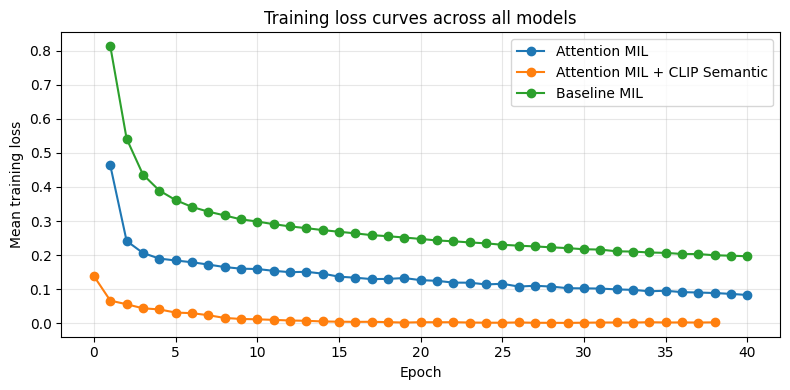

,model_name,epoch,loss_for_plot,loss_type
0,Baseline MIL,1,0.812747,MIL training loss
1,Baseline MIL,2,0.541557,MIL training loss
2,Baseline MIL,3,0.436519,MIL training loss
3,Baseline MIL,4,0.389708,MIL training loss
4,Baseline MIL,5,0.361669,MIL training loss


Saved figure: /scratch/VAD/experiments/runs/vad_BEST_Final_Run_Zain_ClipWeight_0.05_seg32_both_3d_topkK4_lr1e-05_bs4_seed42_ep40_hc2f41927_20260529_174217/results/figures/clip_semantic_loss_breakdown.png


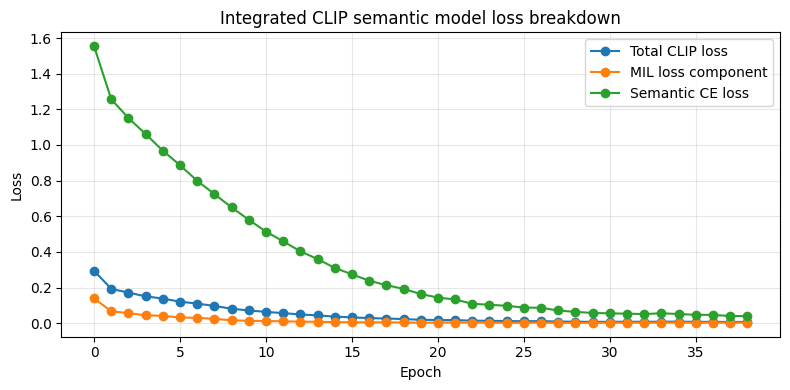

In [21]:
# ============================================================================
# TRAINING LOSS CURVES FOR BASELINE + ATTENTION + INTEGRATED CLIP MODEL
# ============================================================================
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Figure saving
# ---------------------------------------------------------------------------
def _sanitize_fig_name(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9\-_.]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_.")
    return name or "figure"


FIGURES_DIR = (RESULTS_DIR / "figures") if "RESULTS_DIR" in globals() else (Path.cwd() / "figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name: str, fig=None, *, dpi: int = 200, close: bool = False) -> Path:
    fig = fig or plt.gcf()
    out = FIGURES_DIR / f"{_sanitize_fig_name(name)}.png"
    fig.savefig(out, dpi=dpi, bbox_inches="tight")
    if close:
        plt.close(fig)
    print(f"Saved figure: {out}")
    return out


# ---------------------------------------------------------------------------
# 1) Load baseline + attention history
# ---------------------------------------------------------------------------
history_rows = []

# Preferred: use existing long-format history if available
if "history_long_df" in globals() and history_long_df is not None and not history_long_df.empty:
    base_hist = history_long_df.copy()

    # Standardise columns
    if "model_name" not in base_hist.columns and "model" in base_hist.columns:
        base_hist = base_hist.rename(columns={"model": "model_name"})

    if "train_loss" in base_hist.columns and "epoch" in base_hist.columns:
        for _, row in base_hist.iterrows():
            history_rows.append(
                {
                    "model_name": row["model_name"],
                    "epoch": int(row["epoch"]),
                    "loss_for_plot": float(row["train_loss"]),
                    "loss_type": "MIL training loss",
                }
            )

# Fallback: load wide-format training_history.csv if history_long_df is missing
else:
    hist_path = METADATA_DIR / "training_history.csv"

    if hist_path.exists():
        wide_hist = pd.read_csv(hist_path)

        if "baseline_loss" in wide_hist.columns:
            for _, row in wide_hist.iterrows():
                if pd.notna(row["baseline_loss"]):
                    history_rows.append(
                        {
                            "model_name": "Baseline MIL",
                            "epoch": int(row["epoch"]),
                            "loss_for_plot": float(row["baseline_loss"]),
                            "loss_type": "MIL training loss",
                        }
                    )

        if "attention_loss" in wide_hist.columns:
            for _, row in wide_hist.iterrows():
                if pd.notna(row["attention_loss"]):
                    history_rows.append(
                        {
                            "model_name": "Attention MIL",
                            "epoch": int(row["epoch"]),
                            "loss_for_plot": float(row["attention_loss"]),
                            "loss_type": "MIL training loss",
                        }
                    )

    else:
        print("No baseline/attention training history found.")


# ---------------------------------------------------------------------------
# 2) Load integrated CLIP semantic history
# ---------------------------------------------------------------------------
clip_hist_path = METADATA_DIR / "training_history_attention_clip_semantic.csv"

if clip_hist_path.exists():
    clip_hist = pd.read_csv(clip_hist_path)

    # For fair comparison with MIL models, plot the MIL part of the CLIP loss.
    # Total CLIP loss = MIL loss + semantic_loss_weight * semantic CE loss,
    # so it is not directly comparable to baseline/attention MIL loss.
    clip_loss_col = "train_mil_loss" if "train_mil_loss" in clip_hist.columns else "train_loss"

    for _, row in clip_hist.iterrows():
        if pd.notna(row[clip_loss_col]):
            history_rows.append(
                {
                    "model_name": "Attention MIL + CLIP Semantic",
                    "epoch": int(row["epoch"]),
                    "loss_for_plot": float(row[clip_loss_col]),
                    "loss_type": clip_loss_col,
                }
            )

    print(f"Loaded CLIP semantic training history from: {clip_hist_path}")
    print(f"Using CLIP loss column for comparison: {clip_loss_col}")

else:
    print(f"CLIP semantic history not found: {clip_hist_path}")
    print("Run the integrated CLIP training cell first if you want it on this curve.")


# ---------------------------------------------------------------------------
# 3) Plot combined comparable training loss curve
# ---------------------------------------------------------------------------
combined_history_df = pd.DataFrame(history_rows)

if combined_history_df.empty:
    print("No training history available to plot.")

else:
    plt.figure(figsize=(8, 4))

    for model_name, group in combined_history_df.groupby("model_name"):
        group = group.sort_values("epoch")
        plt.plot(
            group["epoch"],
            group["loss_for_plot"],
            marker="o",
            label=model_name,
        )

    plt.xlabel("Epoch")
    plt.ylabel("Mean training loss")
    plt.title("Training loss curves across all models")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_fig("train_loss_curves_all_models_with_clip")
    plt.show()

    display(combined_history_df.head())


# ---------------------------------------------------------------------------
# 4) Optional: plot CLIP total/MIL/semantic loss breakdown separately
# ---------------------------------------------------------------------------
if clip_hist_path.exists():
    clip_hist = pd.read_csv(clip_hist_path)

    plt.figure(figsize=(8, 4))

    if "train_loss" in clip_hist.columns:
        plt.plot(
            clip_hist["epoch"],
            clip_hist["train_loss"],
            marker="o",
            label="Total CLIP loss",
        )

    if "train_mil_loss" in clip_hist.columns:
        plt.plot(
            clip_hist["epoch"],
            clip_hist["train_mil_loss"],
            marker="o",
            label="MIL loss component",
        )

    if "train_semantic_loss" in clip_hist.columns:
        plt.plot(
            clip_hist["epoch"],
            clip_hist["train_semantic_loss"],
            marker="o",
            label="Semantic CE loss",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Integrated CLIP semantic model loss breakdown")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_fig("clip_semantic_loss_breakdown")
    plt.show()

# 21. Combined model comparison export

This section creates a final combined model comparison table for all trained models.

The output includes:

```text
model name
best validation AUC
best validation AP
best epoch
checkpoint path
parameter counts
training time
semantic metrics where available
```

The combined table is saved for later use in the final evaluation notebook and report preparation.


In [22]:
# ============================================================================
# DISPLAY MODEL COMPARISON: BASELINE + ATTENTION + INTEGRATED CLIP
# ============================================================================
import pandas as pd
import numpy as np
import torch
from pathlib import Path

base_path = METADATA_DIR / "model_comparison.csv"
clip_path = METADATA_DIR / "model_comparison_attention_clip_semantic.csv"
clip_history_path = METADATA_DIR / "training_history_attention_clip_semantic.csv"

if not base_path.exists():
    raise FileNotFoundError(f"Missing model comparison file: {base_path}")

# ---------------------------------------------------------------------------
# Load Baseline MIL + Attention MIL comparison
# ---------------------------------------------------------------------------
base_df = pd.read_csv(base_path)

# Keep existing baseline/attention format
comparison_rows = []

for _, row in base_df.iterrows():
    comparison_rows.append(
        {
            "model_key": row.get("model_key", ""),
            "model_name": row.get("model_name", row.get("Model", "")),
            "best_val_auc": row.get("best_val_auc", row.get("Best AUC", np.nan)),
            "best_val_ap": row.get("best_val_ap", row.get("Best AP", np.nan)),
            "best_epoch": row.get("best_epoch", row.get("Best Epoch", np.nan)),
            "checkpoint_path": row.get("checkpoint_path", row.get("Checkpoint", "")),
            "total_params": row.get("total_params", row.get("num_parameters", np.nan)),
            "trainable_params": row.get("trainable_params", row.get("trainable_parameters", np.nan)),
            "total_train_seconds": row.get("total_train_seconds", np.nan),
            "semantic_loss_weight": np.nan,
            "val_semantic_accuracy": np.nan,
            "val_semantic_macro_f1": np.nan,
            "val_semantic_weighted_f1": np.nan,
        }
    )

# ---------------------------------------------------------------------------
# Load Integrated CLIP semantic comparison if available
# ---------------------------------------------------------------------------
if clip_path.exists():
    clip_df = pd.read_csv(clip_path)

    clip_history_df = None
    clip_total_train_seconds = np.nan

    if clip_history_path.exists():
        clip_history_df = pd.read_csv(clip_history_path)

        if "epoch_seconds" in clip_history_df.columns:
            clip_total_train_seconds = float(clip_history_df["epoch_seconds"].sum())

    for _, row in clip_df.iterrows():
        best_epoch = int(row.get("Best Epoch", row.get("best_epoch", -1)))

        sem_acc = np.nan
        sem_macro_f1 = np.nan
        sem_weighted_f1 = np.nan

        if clip_history_df is not None and "epoch" in clip_history_df.columns:
            match = clip_history_df[clip_history_df["epoch"] == best_epoch]

            if len(match) > 0:
                best_hist = match.iloc[-1]
                sem_acc = best_hist.get("val_semantic_accuracy", np.nan)
                sem_macro_f1 = best_hist.get("val_semantic_macro_f1", np.nan)
                sem_weighted_f1 = best_hist.get("val_semantic_weighted_f1", np.nan)

        ckpt_path = row.get(
            "Checkpoint",
            str(METADATA_DIR / "mil_best_attention_clip_semantic.pth"),
        )

        # Parameter count if in-memory model exists
        if "attention_clip_model" in globals() and attention_clip_model is not None:
            total_params = int(sum(p.numel() for p in attention_clip_model.parameters()))
            trainable_params = int(sum(p.numel() for p in attention_clip_model.parameters() if p.requires_grad))
        else:
            total_params = np.nan
            trainable_params = np.nan

        comparison_rows.append(
            {
                "model_key": row.get("model_key", "attention_clip_semantic"),
                "model_name": row.get("Model", "Attention MIL + CLIP Semantic"),
                "best_val_auc": row.get("Best Val AUC", row.get("best_val_auc", np.nan)),
                "best_val_ap": row.get("Best Val AP", row.get("best_val_ap", np.nan)),
                "best_epoch": best_epoch,
                "checkpoint_path": ckpt_path,
                "total_params": total_params,
                "trainable_params": trainable_params,
                "total_train_seconds": clip_total_train_seconds,
                "semantic_loss_weight": row.get("Semantic Loss Weight", np.nan),
                "val_semantic_accuracy": sem_acc,
                "val_semantic_macro_f1": sem_macro_f1,
                "val_semantic_weighted_f1": sem_weighted_f1,
            }
        )

else:
    print("Integrated CLIP comparison file not found yet.")
    print("Run the integrated CLIP training cell first if you want CLIP results in this table.")

# ---------------------------------------------------------------------------
# Display and save combined table
# ---------------------------------------------------------------------------
comparison_all_df = pd.DataFrame(comparison_rows)

numeric_cols = [
    "best_val_auc",
    "best_val_ap",
    "total_train_seconds",
    "semantic_loss_weight",
    "val_semantic_accuracy",
    "val_semantic_macro_f1",
    "val_semantic_weighted_f1",
]

for col in numeric_cols:
    if col in comparison_all_df.columns:
        comparison_all_df[col] = pd.to_numeric(comparison_all_df[col], errors="coerce").round(6)

combined_path = METADATA_DIR / "model_comparison_all_models.csv"
comparison_all_df.to_csv(combined_path, index=False)

print("=" * 80)
print("MODEL COMPARISON: BASELINE + ATTENTION + INTEGRATED CLIP")
print("=" * 80)
print("Saved:", combined_path)

display(comparison_all_df)

MODEL COMPARISON: BASELINE + ATTENTION + INTEGRATED CLIP
Saved: /scratch/VAD/artifacts/metadata/model_comparison_all_models.csv


,model_key,model_name,best_val_auc,best_val_ap,best_epoch,checkpoint_path,total_params,trainable_params,total_train_seconds,semantic_loss_weight,val_semantic_accuracy,val_semantic_macro_f1,val_semantic_weighted_f1
0,baseline_mil,Baseline MIL,0.934666,0.931472,40,/scratch/VAD/artifacts/metadata/mil_best_basel...,263169,263169,420.807853,NaN,NaN,NaN,NaN
1,attention_mil,Attention MIL,0.957949,0.949158,33,/scratch/VAD/artifacts/metadata/mil_best_atten...,1743873,1743873,726.937139,NaN,NaN,NaN,NaN
2,attention_clip_semantic,Attention MIL + CLIP Semantic,0.991993,0.992366,28,/scratch/VAD/artifacts/metadata/mil_best_atten...,1941762,1941762,1180.603486,0.1,0.949566,0.297649,0.948566


# 22. Top-k pooling rationale

In weakly supervised MIL, segment-level anomaly scores must be aggregated into a single video-level score.

A simple option is max pooling:

```text
video score = highest segment score
```

However, max pooling can be sensitive to a single noisy segment. It also sends most of the gradient signal through only one segment.

Top-k mean pooling uses the average of the highest-scoring `K` segments:

```text
video score = mean(top K segment scores)
```

For the submitted configuration:

```text
K = 4
```

Top-k pooling is used because it is more stable than relying on a single maximum segment and is better suited to anomalies that span multiple temporal segments.


# 23. Pooling comparison for trained models

This section evaluates the trained model checkpoints using different video-level pooling strategies.

The comparison includes:

```text
max pooling
top-k pooling
```

for validation and test splits.

The results are saved to:

```text
pooling_comparison.csv
```

This file is used to support the final discussion of why top-k pooling was selected as the main scoring method.


In [23]:
# ============================================================================
# POOLING COMPARISON FOR ALL TRAINED MODELS
# ============================================================================
import pandas as pd
import numpy as np
import torch


def torch_load_checkpoint(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def load_model_from_spec(spec):
    model = spec["cls"](**spec["kwargs"]).to(device)

    ckpt = torch_load_checkpoint(spec["ckpt"])
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    return model, ckpt


@torch.no_grad()
def evaluate_model_with_pooling(model, loader, pooling="topk", topk_k=4):
    model.eval()

    all_labels = []
    all_scores = []

    for xb, yb, lb in loader:
        xb = xb.float().to(device)
        lb = lb.to(device)

        logits = forward_model(model, xb, lb)
        seg_scores = torch.sigmoid(logits)

        if pooling == "max":
            video_scores = max_pool_masked(seg_scores, lb)
        elif pooling == "topk":
            video_scores = topk_mean_masked(seg_scores, lb, k=topk_k)
        else:
            raise ValueError(f"Unknown pooling mode: {pooling}")

        all_labels.extend(yb.detach().cpu().numpy().astype(int).tolist())
        all_scores.extend(video_scores.detach().cpu().numpy().tolist())

    auc = safe_metric_auc(all_labels, all_scores)
    ap = safe_metric_ap(all_labels, all_scores)

    return auc, ap


pooling_rows = []

for spec in MODEL_SPECS:
    model, ckpt = load_model_from_spec(spec)

    for split_name, loader in [
        ("val", val_loader),
        ("test", test_loader),
    ]:
        for pooling in ["max", "topk"]:
            auc, ap = evaluate_model_with_pooling(
                model,
                loader,
                pooling=pooling,
                topk_k=TOPK_K,
            )

            pooling_rows.append(
                {
                    "model_key": spec["model_key"],
                    "model_name": spec["display_name"],
                    "split": split_name,
                    "pooling": pooling,
                    "topk_k": TOPK_K if pooling == "topk" else np.nan,
                    "auc": auc,
                    "ap": ap,
                    "checkpoint": str(spec["ckpt"]),
                    "best_epoch": ckpt.get("epoch", np.nan),
                }
            )

pooling_df = pd.DataFrame(pooling_rows)

pooling_path = METADATA_DIR / "pooling_comparison.csv"
pooling_df.to_csv(pooling_path, index=False)

print("=" * 80)
print("POOLING COMPARISON COMPLETE")
print("=" * 80)
print("Saved:", pooling_path)
display(pooling_df)

POOLING COMPARISON COMPLETE
Saved: /scratch/VAD/artifacts/metadata/pooling_comparison.csv


,model_key,model_name,split,pooling,topk_k,auc,ap,checkpoint,best_epoch
0,baseline_mil,Baseline MIL,val,max,NaN,0.929741,0.926257,/scratch/VAD/artifacts/metadata/mil_best_basel...,40
1,baseline_mil,Baseline MIL,val,topk,4.0,0.934666,0.931472,/scratch/VAD/artifacts/metadata/mil_best_basel...,40
2,baseline_mil,Baseline MIL,test,max,NaN,0.928595,0.952006,/scratch/VAD/artifacts/metadata/mil_best_basel...,40
3,baseline_mil,Baseline MIL,test,topk,4.0,0.932097,0.953055,/scratch/VAD/artifacts/metadata/mil_best_basel...,40
4,attention_mil,Attention MIL,val,max,NaN,0.948582,0.927275,/scratch/VAD/artifacts/metadata/mil_best_atten...,33
5,attention_mil,Attention MIL,val,topk,4.0,0.957949,0.949158,/scratch/VAD/artifacts/metadata/mil_best_atten...,33
6,attention_mil,Attention MIL,test,max,NaN,0.945665,0.952253,/scratch/VAD/artifacts/metadata/mil_best_atten...,33
7,attention_mil,Attention MIL,test,topk,4.0,0.951506,0.961032,/scratch/VAD/artifacts/metadata/mil_best_atten...,33
